# Лабораторная работа №2
## Морфологический анализ, POS-tagging и извлечение синтаксических структур

**Цель работы:** Освоить методы автоматического извлечения грамматических признаков и синтаксических связей из неструктурированного текста для выделения ключевых смысловых объектов и паттернов.

Продолжаем работать с Amazon Product Reviews из первой лабораторной. Сначала разметим корпус и сравним части речи, затем разберём ошибки, построим 10 деревьев, извлечём топ-20 пар и реализуем разрешение анафоры.

Здесь используем исходный `Text`, а не `clean` из первой работы. Нижний регистр, удаление служебных слов и замена чисел были полезны для других задач, но при синтаксическом анализе могут уничтожить признаки, нужные модели. Обучения на корпусе нет: используем готовую модель и анализируем весь отобранный корпус без train/test.

Для запуска нужны `numpy`, `pandas`, `matplotlib`, `seaborn`, `spacy`, `kagglehub` и модель `en_core_web_sm`. 

Для установки недостающих пакетов выполнить:
```python
%pip install numpy pandas matplotlib seaborn spacy==3.8.16 kagglehub
import sys
!{sys.executable} -m spacy download en_core_web_sm
```

In [1]:
import os
import sys
import re
import random
import json
from pathlib import Path
from collections import Counter, deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from IPython.display import display, HTML, Markdown, SVG
from spacy import displacy
from spacy.tokens import DocBin
import kagglehub

In [2]:
SEED = 42
DATA_DIR = "data"
FIG_DIR = "figures"

random.seed(SEED)
np.random.seed(SEED)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 300)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)

Сразу зададим единый стиль всех визуализаций

In [3]:
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
import xml.etree.ElementTree as ET

INK, MUTED, GRID, PAPER = "#233249", "#64748B", "#E2E8EF", "#FAFBFD"
TEAL, CORAL, GOLD, BLUE = "#168F87", "#D06B60", "#B88A35", "#5478A7"
GROUPS = ["negative", "neutral", "positive"]
GROUP_LABELS = ["Негативные · 1–2", "Нейтральные · 3", "Позитивные · 4–5"]
GROUP_COLORS = [CORAL, GOLD, TEAL]
sns.set_theme(style="white", font="DejaVu Sans")
plt.rcParams.update({"figure.facecolor": PAPER, "axes.facecolor": PAPER,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED,
    "ytick.color": INK, "font.size": 11, "axes.labelsize": 10,
    "axes.titleweight": "bold", "axes.spines.top": False,
    "axes.spines.right": False, "axes.spines.left": False,
    "axes.spines.bottom": False, "savefig.facecolor": PAPER,
    "figure.dpi": 120, "svg.fonttype": "none"})

def chart_header(fig, title, subtitle):
    fig.text(0.03, 0.96, title, fontsize=20, weight="bold", va="top")
    fig.text(0.03, 0.912, subtitle, fontsize=10.5, color=MUTED, va="top")

In [4]:
print("spaCy:", spacy.__version__)

spaCy: 3.8.16


### Шаг 1. Загрузка датасета

Источник - Amazon Product Reviews. Сохраняем исходный регистр, пунктуацию и стоп-слова. Они нужны для морфологического и синтаксического анализа.


In [5]:
csv_path = Path(DATA_DIR) / "7817_1.csv"

if not csv_path.exists():
    path = kagglehub.dataset_download("yasserh/amazon-product-reviews-dataset")
    csv_path = Path(path) / "7817_1.csv"
    
df_raw = pd.read_csv(csv_path)
required = {"reviews.text", "reviews.rating"}

print("Размер исходного датасета:", df_raw.shape)

Размер исходного датасета: (1597, 27)


In [6]:
display(df_raw[["reviews.text", "reviews.rating"]].head())

,reviews.text,reviews.rating
0,"I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing: the paperwhite is great, but if you have spending money, go for the voyage.Fortunately, I had friends who owned each, so I ended up buying the paperwhite on this basis: both m...",5.0
1,"Allow me to preface this with a little history. I am (was) a casual reader who owned a Nook Simple Touch from 2011. I've read the Harry Potter series, Girl with the Dragon Tattoo series, 1984, Brave New World, and a few other key titles. Fair to say my Nook did not get as much use as many others...",5.0
2,I am enjoying it so far. Great for reading. Had the original Fire since 2012. The Fire used to make my eyes hurt if I read too long. Haven't experienced that with the Paperwhite yet.,4.0
3,"I bought one of the first Paperwhites and have been very pleased with it its been a constant companion and I suppose Ive read, on average, a book every three days for the past however many years on it. I wouldnt give it up youd have to pry it from my cold dead fingers.For sundry logistical reaso...",5.0
4,"I have to say upfront - I don't like coroporate, hermetically closed stuff like anything by Apple or in this case, Amazon. I like having devices on which I can put anything I want and use it. But...I was a fairly happy user of a Nook Touch for several years, but couldn't use all its functionalit...",5.0


#### Подготовим рабочий DataFrame

In [7]:
df = df_raw[["reviews.text", "reviews.rating"]].rename(
    columns={"reviews.text": "Text", "reviews.rating": "Score"}
).copy()
df["source_row"] = df_raw.index
preparation = [{"Stage": "Исходные строки", "Rows": len(df)}]

In [8]:
df = df.dropna(subset=["Text", "Score"]).copy()
preparation.append({"Stage": "Без пропусков текста и рейтинга", "Rows": len(df)})

In [9]:
df["Text"] = df["Text"].astype(str).str.strip()
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

Проверяем допустимость ДО astype(int), чтобы 4.5 не превратилось в 4.

In [10]:
df = df[df["Score"].isin([1, 2, 3, 4, 5])].copy()
df["Score"] = df["Score"].astype(int)
preparation.append({"Stage": "Корректный целый рейтинг 1-5", "Rows": len(df)})

In [11]:
df = df[df["Text"].ne("")].copy()
preparation.append({"Stage": "Без пустых текстов", "Rows": len(df)})

Одинаковый текст с разными оценками нельзя однозначно отнести к группе

In [12]:
rating_variation = df.groupby("Text")["Score"].nunique()
conflicting_texts = rating_variation[rating_variation > 1].index
conflicts = df[df["Text"].isin(conflicting_texts)].copy()
conflicts.to_csv(Path(DATA_DIR) / "conflicting_reviews.csv", index=False)
print("Текстов с конфликтующими оценками:", len(conflicting_texts))

Текстов с конфликтующими оценками: 1


In [13]:
df = df[~df["Text"].isin(conflicting_texts)].copy()
preparation.append({"Stage": "Без конфликтующих оценок", "Rows": len(df)})

df = df.drop_duplicates(subset=["Text"]).reset_index(drop=True)
preparation.append({"Stage": "Без повторов текста", "Rows": len(df)})

display(pd.DataFrame(preparation))

,Stage,Rows
0,Исходные строки,1597
1,Без пропусков текста и рейтинга,1177
2,Корректный целый рейтинг 1-5,1177
3,Без пустых текстов,1177
4,Без конфликтующих оценок,1173
5,Без повторов текста,907


In [14]:
df["Sentiment"] = pd.cut(
    df["Score"],
    bins=[0, 2, 3, 5],
    labels=["negative", "neutral", "positive"]
)

In [15]:
print("Размер корпуса:", df.shape)
print("Распределение рейтингов:")

Размер корпуса: (907, 4)
Распределение рейтингов:


In [16]:
print(df["Score"].value_counts().sort_index())

Score
1     41
2     31
3     70
4    200
5    565
Name: count, dtype: int64


In [17]:
print("Распределение групп:")
print(df["Sentiment"].value_counts())

Распределение групп:
Sentiment
positive    765
negative     72
neutral      70
Name: count, dtype: int64


In [18]:
display(df.head())

,Text,Score,source_row,Sentiment
0,"I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing: the paperwhite is great, but if you have spending money, go for the voyage.Fortunately, I had friends who owned each, so I ended up buying the paperwhite on this basis: both m...",5,0,positive
1,"Allow me to preface this with a little history. I am (was) a casual reader who owned a Nook Simple Touch from 2011. I've read the Harry Potter series, Girl with the Dragon Tattoo series, 1984, Brave New World, and a few other key titles. Fair to say my Nook did not get as much use as many others...",5,1,positive
2,I am enjoying it so far. Great for reading. Had the original Fire since 2012. The Fire used to make my eyes hurt if I read too long. Haven't experienced that with the Paperwhite yet.,4,2,positive
3,"I bought one of the first Paperwhites and have been very pleased with it its been a constant companion and I suppose Ive read, on average, a book every three days for the past however many years on it. I wouldnt give it up youd have to pry it from my cold dead fingers.For sundry logistical reaso...",5,3,positive
4,"I have to say upfront - I don't like coroporate, hermetically closed stuff like anything by Apple or in this case, Amazon. I like having devices on which I can put anything I want and use it. But...I was a fairly happy user of a Nook Touch for several years, but couldn't use all its functionalit...",5,4,positive


#### Выводы по подготовке данных

Из 1 597 исходных строк после исключения пропусков текста и рейтинга остаётся 1 177. 

Обнаружен один текст с противоречивыми оценками `Read more`. Он повторяется четыре раза с рейтингами 4 и 5. Все четыре строки исключены, затем удалены повторы остальных текстов. Итог - **907 уникальных отзывов**.

В первой лабораторной было 908 отзывов, потому что для `Read more` сохранялся первый встретившийся рейтинг. Разница в одну запись объясняется новым правилом, а не потерей датасета.

Положительная группа содержит 765 отзывов (84.34%), отрицательная - 72 (7.94%), нейтральная - 70 (7.72%). Поэтому абсолютное число прилагательных или глаголов почти неизбежно будет выше в положительной группе. Для сравнения стиля нужны относительные частоты. Группы задаются рейтингом. Отдельное предложение внутри отзыва может иметь другую тональность.

**Дубликаты и ограничения корпуса.** 

Повторяющийся текст учитываем один раз. Если у одного текста разные оценки, исключаем все его варианты и сохраняем их отдельно: выбор первой оценки был бы произвольным. Поэтому получено 907 отзывов вместо прежних 908.

`Sentiment` - условная группа по рейтингу (1–2, 3, 4–5), а не ручная разметка эмоциональной окраски текста. Группы не сбалансированы. Сравниваем доли, а не абсолютное число токенов. В исходных результатах обнаружен французский отзыв, то есть корпус не гарантированно англоязычный. Не будем называть необычные теги в таких текстах доказанными ошибками английской модели.

### Шаг 2. POS-tagging всего корпуса

Загружаем модель

In [19]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])

print("spaCy:", spacy.__version__)
print("Модель:", nlp.meta.get("name"), nlp.meta.get("version"))
print("Компоненты pipeline:", nlp.pipe_names)

spaCy: 3.8.16
Модель: core_web_sm 3.8.0
Компоненты pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer']


`spaCy` - это библиотека обработки естественного языка. Модель `en_core_web_sm` включает токенизацию, морфологическую разметку, синтаксический анализ и другие компоненты для английского языка.

Сначала проверим результат на небольшом примере

In [20]:
example = (
    "I love this phone. "
    "The screen is bright, but the battery is weak."
)

In [21]:
doc = nlp(example)
rows = []

In [22]:
for token in doc:
    rows.append({"Token": token.text, "Lemma": token.lemma_, "POS": token.pos_,
                 "Tag": token.tag_, "Dependency": token.dep_, "Head": token.head.text,
                 "Morphology": str(token.morph)})

In [23]:
example_df = pd.DataFrame(rows)
display(example_df)

,Token,Lemma,POS,Tag,Dependency,Head,Morphology
0,I,I,PRON,PRP,nsubj,love,Case=Nom|Number=Sing|Person=1|PronType=Prs
1,love,love,VERB,VBP,ROOT,love,Tense=Pres|VerbForm=Fin
2,this,this,DET,DT,det,phone,Number=Sing|PronType=Dem
3,phone,phone,NOUN,NN,dobj,love,Number=Sing
4,.,.,PUNCT,.,punct,love,PunctType=Peri
5,The,the,DET,DT,det,screen,Definite=Def|PronType=Art
6,screen,screen,NOUN,NN,nsubj,is,Number=Sing
7,is,be,AUX,VBZ,ROOT,is,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
8,bright,bright,ADJ,JJ,acomp,is,Degree=Pos
9,",",",",PUNCT,",",punct,is,PunctType=Comm


- Token - исходный токен
- Lemma - его начальная форма
- POS - часть речи
- Tag - детальная грамматическая метка
- Dependency - синтаксическая связь
- Head - управляющий токен
- Morphology - морфологические характеристики

#### Обработка всего корпуса

Чтобы не вызывать `nlp()` отдельно для каждого отзыва в цикле, используем `nlp.pipe()`. Он позволяет эффективнее обрабатывать большое количество документов.

In [24]:
texts = df["Text"].tolist()
docs = list(nlp.pipe(texts,batch_size=64))
assert len(docs) == len(df)

print("Обработано отзывов:", len(docs))

Обработано отзывов: 907


И теперь сохраним результаты в DataFrame

In [25]:
token_rows = []

In [26]:
for doc_id, doc in enumerate(docs):
    for sent_id, sent in enumerate(doc.sents):
        for token in sent:
            if token.is_space:
                continue
            token_rows.append({
                "doc_id": doc_id, "source_row": int(df.loc[doc_id, "source_row"]),
                "sent_id": sent_id, "token_id": token.i, "char_start": token.idx,
                "Token": token.text, "Lemma": token.lemma_,
                "POS": token.pos_, "Tag": token.tag_,
                "Morphology": str(token.morph),
                "Dependency": token.dep_, "Head": token.head.text,
                "head_id": token.head.i, "Head_POS": token.head.pos_,
                "Sentiment": str(df.loc[doc_id, "Sentiment"]),
                "Score": int(df.loc[doc_id, "Score"]),
                "Is_Punctuation": token.is_punct
            })

In [27]:
tokens_df = pd.DataFrame(token_rows)
display(tokens_df.head(20))

,doc_id,source_row,sent_id,token_id,char_start,Token,Lemma,POS,Tag,Morphology,Dependency,Head,head_id,Head_POS,Sentiment,Score,Is_Punctuation
0,0,0,0,0,0,I,I,PRON,PRP,Case=Nom|Number=Sing|Person=1|PronType=Prs,nsubj,had,2,VERB,positive,5,False
1,0,0,0,1,2,initially,initially,ADV,RB,,advmod,had,2,VERB,positive,5,False
2,0,0,0,2,12,had,have,VERB,VBD,Tense=Past|VerbForm=Fin,ROOT,had,2,VERB,positive,5,False
3,0,0,0,3,16,trouble,trouble,NOUN,NN,Number=Sing,dobj,had,2,VERB,positive,5,False
4,0,0,0,4,24,deciding,decide,VERB,VBG,Aspect=Prog|Tense=Pres|VerbForm=Part,acl,trouble,3,NOUN,positive,5,False
5,0,0,0,5,33,between,between,ADP,IN,,prep,deciding,4,VERB,positive,5,False
6,0,0,0,6,41,the,the,DET,DT,Definite=Def|PronType=Art,det,paperwhite,7,NOUN,positive,5,False
7,0,0,0,7,45,paperwhite,paperwhite,NOUN,NN,Number=Sing,pobj,between,5,ADP,positive,5,False
8,0,0,0,8,56,and,and,CCONJ,CC,ConjType=Cmp,cc,paperwhite,7,NOUN,positive,5,False
9,0,0,0,9,60,the,the,DET,DT,Definite=Def|PronType=Art,det,voyage,10,NOUN,positive,5,False


In [28]:
print("Всего токенов:", len(tokens_df))
print("Уникальных POS-категорий:", tokens_df["POS"].nunique())

Всего токенов: 110373
Уникальных POS-категорий: 17


`tokens_df` содержит POS, морфологию и связи с управляющими токенами. Пара `(doc_id, token_id)` однозначно определяет вхождение слова. CSV удобен для таблиц, а `DocBin` сохраняет размеченные документы для повторного использования.


In [29]:
tokens_df.to_csv(Path(DATA_DIR) / "pos_tagging_results.csv", index=False)
df.to_csv(Path(DATA_DIR) / "reviews_clean.csv", index=False)

DocBin(docs=docs).to_disk(Path(DATA_DIR) / "reviews.spacy")
versions = {"python": sys.version, "spacy": spacy.__version__,
            "model": nlp.meta.get("name"), "model_version": nlp.meta.get("version"),
            "seed": SEED, "reviews": len(df)}

(Path(DATA_DIR) / "run_metadata.json").write_text(
    json.dumps(versions, ensure_ascii=False, indent=2), encoding="utf-8"
)

220

### Шаг 3. Частотное распределение частей речи

Исключаем пунктуацию по двум признакам: лексическому `is_punct` и предсказанному POS=`PUNCT`. Они могут расходиться. Так в исходной таблице после фильтрации только по `is_punct` осталось 16 токенов с POS=`PUNCT`. Остальные категории, включая NUM, SYM и X, оставляем. Проценты считаются от всех оставшихся токенов.


In [30]:
punctuation_mask = tokens_df["Is_Punctuation"] | tokens_df["POS"].eq("PUNCT")
content_tokens = tokens_df.loc[~punctuation_mask].copy()
assert not content_tokens["POS"].eq("PUNCT").any()

print("Токенов в знаменателе POS-статистики:", len(content_tokens))

Токенов в знаменателе POS-статистики: 98702


In [31]:
pos_counts = (content_tokens["POS"].value_counts().rename_axis("POS").reset_index(name="Count"))

In [32]:
pos_counts["Percent"] = (pos_counts["Count"] / pos_counts["Count"].sum() * 100)

In [33]:
display(pos_counts)

,POS,Count,Percent
0,NOUN,17722,17.955057
1,VERB,12687,12.853843
2,PRON,11826,11.981520
3,DET,9738,9.866061
4,ADP,9012,9.130514
5,ADJ,7736,7.837734
6,AUX,7001,7.093068
7,ADV,5812,5.888432
8,PROPN,5521,5.593605
9,CCONJ,3835,3.885433


In [34]:
pos_names = {"NOUN": "Существительные", "VERB": "Глаголы", "PRON": "Местоимения", "DET": "Определители", "ADP": "Предлоги", "ADJ": "Прилагательные",
             "AUX": "Вспомогательные глаголы", "ADV": "Наречия", "PROPN": "Имена собственные", "CCONJ": "Сочинительные союзы", "PART": "Частицы", "SCONJ": "Подчинительные союзы"}

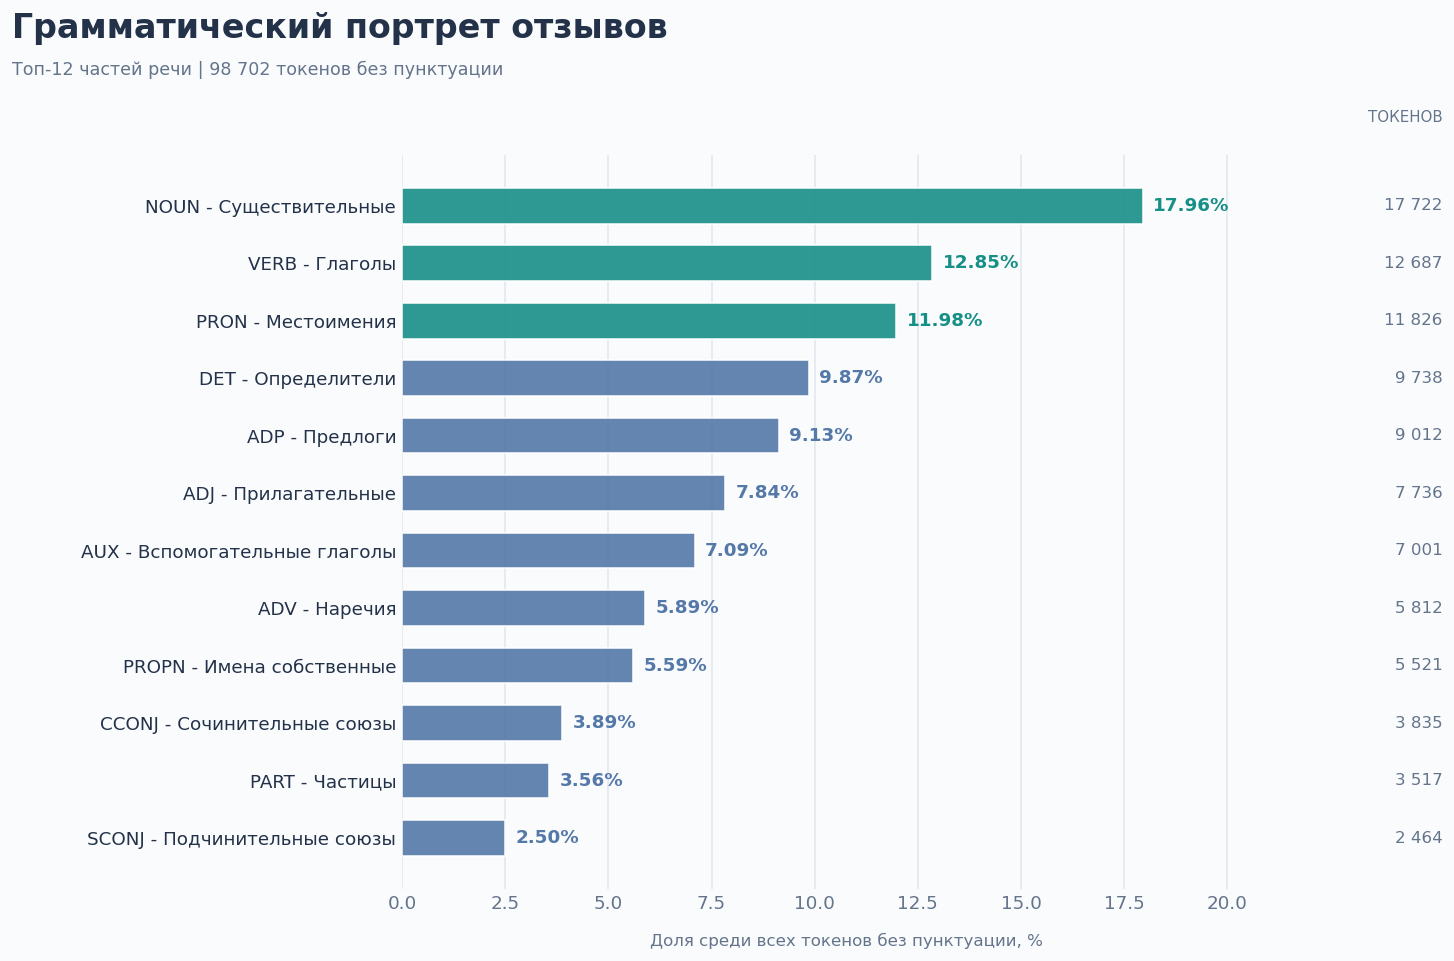

In [35]:
top_pos = pos_counts.head(12).copy()
fig, ax = plt.subplots(figsize=(13, 8.5))
fig.subplots_adjust(left=0.28, right=0.85, top=0.82, bottom=0.10)

chart_header(fig, "Грамматический портрет отзывов", f"Топ-12 частей речи | {len(content_tokens):,} токенов без пунктуации".replace(",", " "))
y = np.arange(len(top_pos))

colors = [TEAL if i < 3 else BLUE for i in y]

ax.barh(y, top_pos.Percent, color=colors, height=0.62, alpha=0.9)
ax.set_yticks(y, [f"{r.POS} - {pos_names.get(r.POS, r.POS)}" for r in top_pos.itertuples()])
ax.invert_yaxis()

for i, r in enumerate(top_pos.itertuples()):
    ax.text(r.Percent + 0.25, i, f"{r.Percent:.2f}%", va="center", weight="bold", color=colors[i])
    ax.text(1.17, i, f"{r.Count:,}".replace(",", " "), transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=10, color=MUTED)

ax.text(1.17, 1.045, "ТОКЕНОВ", transform=ax.transAxes, ha="right", fontsize=9, color=MUTED)
ax.set_xlim(0, top_pos.Percent.max()*1.20)
ax.set_xlabel("Доля среди всех токенов без пунктуации, %", labelpad=12)
ax.xaxis.grid(True, color=GRID)
ax.set_axisbelow(True)
ax.tick_params(axis="both", length=0)

Бирюзовым выделены три лидирующие категории. Остальные POS входят в знаменатель, но не показаны в топ-12

#### Анализ распределения частей речи

Размечено **110 373 токена** без пробелов. После исключения пунктуации по обоим признакам остаётся **98 702 токена**. В исходной разметке 17 POS-категорий, а в распределении без пунктуации - 16.

Чаще всего встречаются существительные (**17.96%**), глаголы (**12.85%**) и местоимения (**11.98%**). Это согласуется с жанром отзывов: авторы называют устройства и их свойства, описывают действия и личный опыт. Однако сами частоты ещё не доказывают, о каких именно действиях или объектах идёт речь - для этого ниже анализируем связи и контексты.

Прилагательные составляют **7.84%**, наречия - **5.89%**, междометия только **0.14%**. Эмоциональность отзыва не сводится к междометиям: оценка может выражаться словами `great`, `poor`, отрицаниями и целыми конструкциями. Кроме того, часть эмоциональных CAPS-слов модель размечает неверно, что покажет ручная проверка.

Служебные слова `DET`, `ADP`, `AUX` занимают заметную долю. Удалять их перед синтаксическим анализом нельзя: они помогают определять именные группы, время и связи между словами.

#### Сравнение групп по рейтингу
Сначала считаем доли среди **всех токенов группы**. Это корректирует разный объём групп, но длинные отзывы всё ещё имеют больший вес. Ниже дополнительно усредняем доли **по отзывам**, чтобы каждый отзыв имел одинаковый вес.


In [36]:
pos_by_sentiment = pd.crosstab(content_tokens["Sentiment"], content_tokens["POS"], normalize="index") * 100
display(pos_by_sentiment.round(2))

POS,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,NUM,PART,PRON,PROPN,SCONJ,SYM,VERB,X
Sentiment,,,,,,,,,,,,,,,,
negative,6.76,9.39,6.66,7.63,3.44,10.12,0.14,17.63,1.62,3.96,12.23,4.21,2.36,0.01,13.82,0.03
neutral,8.11,8.97,6.38,7.65,3.91,9.63,0.08,17.45,1.61,4.40,11.43,4.82,2.66,0.01,12.79,0.10
positive,7.90,9.13,5.76,6.98,3.92,9.87,0.15,18.04,1.60,3.43,12.03,5.80,2.49,0.04,12.78,0.08


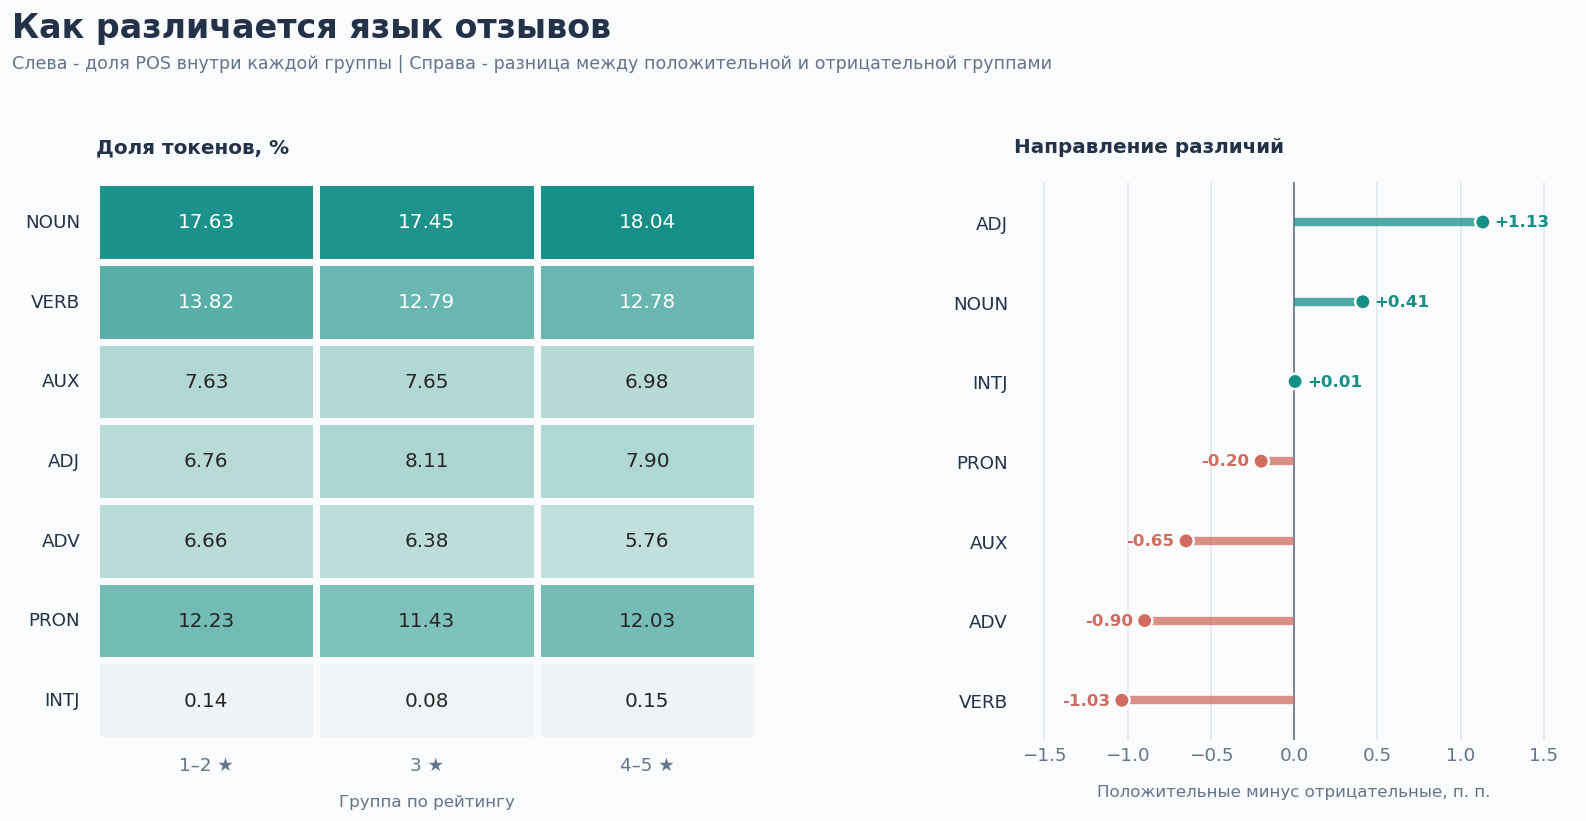

In [37]:
selected_pos = ["NOUN", "VERB", "AUX", "ADJ", "ADV", "PRON", "INTJ"]

matrix = pos_by_sentiment.reindex(index=GROUPS, columns=selected_pos).T

delta = (matrix["positive"] - matrix["negative"]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 7.5), gridspec_kw={"width_ratios": [1.18, 1]})
fig.subplots_adjust(left=0.08, right=0.96, top=0.77, bottom=0.15, wspace=0.42)

chart_header(fig, "Как различается язык отзывов", "Слева - доля POS внутри каждой группы | Справа - разница между положительной и отрицательной группами")
cmap = LinearSegmentedColormap.from_list("mint", ["#F0F4F6", "#A6D3CE", TEAL])

sns.heatmap(matrix, ax=axes[0], cmap=cmap, annot=True, fmt=".2f", linewidths=4,
            linecolor=PAPER, cbar=False, vmin=0, vmax=matrix.to_numpy().max(),
            annot_kws={"fontsize": 12}, square=False)

axes[0].set_xticklabels(["1–2 ★", "3 ★", "4–5 ★"], rotation=0)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[0].set_xlabel("Группа по рейтингу", labelpad=12)
axes[0].set_ylabel("")
axes[0].set_title("Доля токенов, %", loc="left", pad=18, fontsize=12)

ax=axes[1]
yy=np.arange(len(delta))
cc=[TEAL if v>=0 else CORAL for v in delta]

ax.axvline(0, color=MUTED, lw=1)
ax.hlines(yy, 0, delta.values, color=cc, linewidth=5, alpha=0.75)
ax.scatter(delta.values, yy, s=85, c=cc, zorder=3, edgecolors=PAPER, linewidths=1.5)

for i,v in enumerate(delta.values):
    ax.text(v+(0.07 if v>=0 else -0.07), i, f"{v:+.2f}",ha="left" if v>=0 else "right", va="center", fontsize=10, color=cc[i], weight="bold")
    
ax.set_yticks(yy, delta.index)

bound=max(abs(delta.min()),abs(delta.max()))+0.55

ax.set_xlim(-bound,bound)
ax.set_ylim(-0.5,len(delta)-0.5)

ax.set_xlabel("Положительные минус отрицательные, п. п.", labelpad=12)
ax.set_title("Направление различий", loc="left", pad=18, fontsize=12)

ax.xaxis.grid(True,color=GRID)

ax.set_axisbelow(True)
ax.tick_params(length=0)

Значения описательные. Статистическая значимость не проверялась. 

Цвет справа показывает направление, а не качество речи.

#### Средние доли по отдельным отзывам
Сумма долей каждого непустого отзыва равна 100%. Отзывы без учитываемых токенов исключаются только из этой статистики. Различия описательные: сами по себе они не доказывают влияние тональности.


In [38]:
doc_pos = pd.crosstab(content_tokens["doc_id"], content_tokens["POS"])

In [39]:
doc_pos_percent = doc_pos.div(doc_pos.sum(axis=1), axis=0) * 100
doc_pos_percent = doc_pos_percent.join(df["Sentiment"])

In [40]:
mean_pos = doc_pos_percent.groupby("Sentiment", observed=True).mean()

In [41]:
display(mean_pos.reindex(columns=selected_pos, fill_value=0).round(2))

,NOUN,VERB,AUX,ADJ,ADV,PRON,INTJ
Sentiment,,,,,,,
negative,16.88,14.15,8.10,7.61,8.74,11.60,0.07
neutral,16.82,13.99,7.95,9.06,6.16,12.16,0.04
positive,18.15,13.79,6.47,9.92,5.87,13.27,0.08


In [42]:
lengths = doc_pos.sum(axis=1).rename("Tokens").to_frame().join(df["Sentiment"])

In [43]:
display(lengths.groupby("Sentiment", observed=True)["Tokens"].agg(["count", "mean", "median"]).round(2))
mean_pos.to_csv(Path(DATA_DIR) / "mean_pos_per_review.csv")

,count,mean,median
Sentiment,,,
negative,72,96.11,65.0
neutral,70,140.61,66.0
positive,765,107.11,34.0


Посмотрим на длины отзывов целиком. Кривые показывают, какая доля документов не превышает указанное число токенов. Логарифмическая ось позволяет одновременно увидеть короткие отзывы и длинный хвост, не обрезая наблюдения. Пунктиром отмечена медиана - 50% документов.

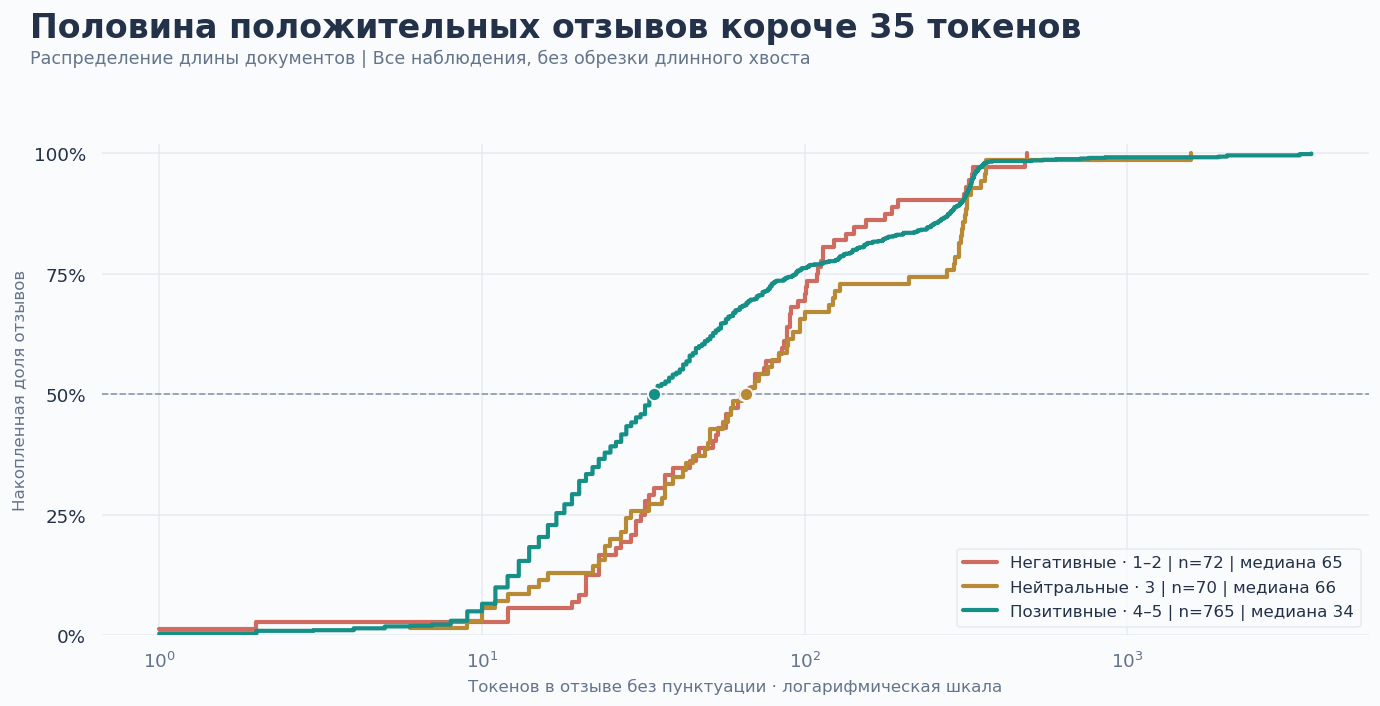

In [44]:
fig,ax=plt.subplots(figsize=(12,6.5))
fig.subplots_adjust(left=0.08,right=0.96,top=0.79,bottom=0.16)

chart_header(fig,"Половина положительных отзывов короче 35 токенов", "Распределение длины документов | Все наблюдения, без обрезки длинного хвоста")

for group,label,color in zip(GROUPS,GROUP_LABELS,GROUP_COLORS):
    values=np.sort(lengths.loc[lengths.Sentiment==group,"Tokens"].to_numpy())
    ax.step(values,np.arange(1,len(values)+1)/len(values)*100,where="post",color=color,lw=2.5, 
                label=f"{label} | n={len(values)} | медиана {np.median(values):.0f}")
    ax.scatter(np.median(values),50,s=60,color=color,edgecolors=PAPER,zorder=5)

ax.axhline(50,color=MUTED,ls="--",lw=1,alpha=0.7)
ax.set_xscale("log")
ax.set_ylim(0,102)
ax.set_yticks([0,25,50,75,100],["0%","25%","50%","75%","100%"])
ax.set_xlabel("Токенов в отзыве без пунктуации · логарифмическая шкала")
ax.set_ylabel("Накопленная доля отзывов")
ax.grid(True,color=GRID,alpha=0.7)
ax.legend(loc="lower right",frameon=True,facecolor=PAPER,edgecolor=GRID,fontsize=10)

Каждый отзыв имеет одинаковый вес. Чем левее кривая, тем короче документы в соответствующей группе.

#### Сравнительный анализ групп

При подсчёте по всем токенам группы доля прилагательных составляет **6.76%** в отрицательных, **8.11%** в нейтральных и **7.90%** в положительных отзывах. То есть прилагательных в положительной группе больше, чем в отрицательной, на **1.13 процентного пункта**, но максимальная доля получается у нейтральной группы. Утверждение "чем положительнее отзыв, тем больше прилагательных" здесь было бы слишком сильным.

Глаголы встречаются чаще в отрицательной группе: **13.82% против 12.78%** в положительной. Наречия тоже: **6.66% против 5.76%**. Возможное объяснение - более подробное описание того, как устройство работает или не работает.

Для междометий различие между отрицательной и положительной группами минимально: **0.145% и 0.150%**. На основании столь редкой категории и без проверки статистической устойчивости нельзя делать вывод о различии эмоциональности.

**Почему важно учитывать длину отзыва?** Медиана длины составляет 65 учитываемых токенов в отрицательной группе, 66 в нейтральной и 34 в положительной. При этом средние длины 96.11, 140.61 и 107.11. Длинные отзывы заметно влияют на средние значения.

Если сначала вычислить доли для каждого отзыва, а затем усреднить их с одинаковым весом, доли ADJ составляют **7.61%, 9.06% и 9.92%** соответственно. Теперь положительная группа выходит на первое место. Значит, результат зависит от единицы усреднения: частота среди токенов описывает общий текстовый объём, а среднее по отзывам типичный документ. Оба показателя полезны, но отвечают на разные вопросы. Статистическая значимость различий здесь не проверялась.

### Шаг 4. Анализ ошибок готового теггера
В первой работе мы нашли CAPS, технические обозначения, склеенные слова и повреждённые фрагменты. Теперь посмотрим, как они влияют на POS-разметку. Метка `X` сама по себе не доказывает ошибку, проверять нужно конкретное вхождение в предложении.

Начнём с кандидатов. Сохраняем `doc_id` и `token_id`, чтобы повторяющееся слово не приводило нас к другому контексту.

In [45]:
candidate_mask = tokens_df["POS"].eq("X") | (tokens_df["Token"].str.fullmatch(r"[A-Z]{3,}", na=False))

In [46]:
candidates = tokens_df.loc[candidate_mask].copy()
candidates["Sentence"] = [docs[int(d)][int(t)].sent.text for d, t in zip(candidates.doc_id, candidates.token_id)]
display(candidates[["doc_id", "token_id", "Token", "POS", "Sentence"]].head(20))

,doc_id,token_id,Token,POS,Sentence
1607,6,200,WIFI,PROPN,"You can browse the Amazon kindle store, and buy books over a WIFI connection* Borrow a book."
1802,6,395,WIFI,PROPN,Access every book you've ever owned on the cloud - available for download within seconds over WIFI or 3G..
1827,6,420,CDN,PROPN,Kindle 6 (around CDN 79)2.
1844,6,437,CDN,PROPN,Kindle Paperwhite 6th Generation (212 dpi - launched October 2013) - around CDN 1292.
1862,6,455,CDN,PROPN,New Kindle Paperwhite 7th Gen (300 dpi - launched July 2015) - around CDN 139-2093.
1898,6,491,CDN,PROPN,"Kindle Fire - 6 or 7 colour tablet computers at around CDN 300-400So you're faced with a few devices, plus additional options."
2016,6,609,a,X,Essentially this means it's (a) Black and White (b) Fantastic to read even in bright sunlight (c) Requires very little power - hence the battery lasts for weeks instead of hours.
2731,6,1324,WIFI,PROPN,"What other options do I have----------------------------------Having decided upon the model (Kindle, Paperwhite, Voyage or Fire), the next decision is around:-* Special Offers - ie. adverts* 3G or WIFI connectionPersonally"
2797,6,1390,WIFI,PROPN,This effectively means you can use your kindle to buy or download books over-the-air instead of at home or near a WIFI hotspot.
2805,6,1398,WIFI,PROPN,"Personally I went for the WIFI model as the saving is considerable, but its a personal choice."


Отобраны семь разных случаев из реального корпуса. Ниже приведена **ручная контекстная оценка**. 

Указанная причина ошибки - объяснение по наблюдаемому контексту, а не доказательство внутреннего механизма модели. Французский отзыв и составные токены вроде `400.With` в эти семь ошибок не включаем, там отдельно возникают проблемы языка и токенизации.

In [47]:
error_specs = [
    ("FINALLY they put the speakers", "FINALLY", "ADV",
     "Наречие времени: наконец установили динамики. CAPS и шумное перечисление; предсказание NOUN неверно."),
    ("has an AWESOME display", "AWESOME", "ADJ",
     "Характеристика display, а не имя собственное. Разговорная оценка в CAPS ошибочно отнесена к PROPN."),
    ("It has GREAT parental controls.", "GREAT", "ADJ",
     "Оценочное прилагательное к controls. CAPS не превращает great в имя собственное."),
    ("We were up running in less than 10 minutes and WOW.", "WOW", "INTJ",
     "Эмоциональное восклицание в разговорной фразе, а не имя собственное."),
    ("I have lights, fans, a thermostat, surround sound, and TV", "thermostat", "NOUN",
     "Название устройства в перечислении после артикля a. Предметный технический термин получил X."),
    ("This is a nice ebook reader.", "ebook", "NOUN",
     "Именной модификатор в ebook reader: название типа книги. Техническое написание ebook получило X."),
    ("If you read the KNOW WHAT YOU ARE BUYING review", "KNOW", "VERB",
     "Внутри цитируемого заголовка KNOW WHAT YOU ARE BUYING это глагол в повелительной конструкции; CAPS и отсутствие кавычек затрудняют разбор.")
]

In [48]:
error_rows = []

In [49]:
for anchor, word, expected, reason in error_specs:
    matches = df.index[df["Text"].str.contains(anchor, regex=False)].tolist()
    if not matches:
        raise ValueError(f"Изменился датасет: не найден пример {anchor}")
    doc_id = matches[0]
    doc = docs[doc_id]
    start = doc.text.index(anchor)
    target = next(t for t in doc if t.text == word and start <= t.idx < start + len(anchor))
    error_rows.append({"doc_id": doc_id, "token_id": target.i,
                       "Sentence": target.sent.text, "Token": target.text,
                       "Predicted_POS": target.pos_, "Correct_POS": expected,
                       "Is_error": target.pos_ != expected, "Analysis": reason})

In [50]:
error_analysis = pd.DataFrame(error_rows)
display(error_analysis[["Token", "Predicted_POS", "Correct_POS", "Is_error"]])

,Token,Predicted_POS,Correct_POS,Is_error
0,FINALLY,NOUN,ADV,True
1,AWESOME,PROPN,ADJ,True
2,GREAT,PROPN,ADJ,True
3,WOW,PROPN,INTJ,True
4,thermostat,X,NOUN,True
5,ebook,X,NOUN,True
6,KNOW,X,VERB,True


In [51]:
for number, r in enumerate(error_analysis.itertuples(), 1):
    display(Markdown(f"**Пример {number}: {r.Token} ({r.Predicted_POS} → {r.Correct_POS}).**"))
    display(Markdown(f"> {r.Sentence}"))
    display(Markdown(r.Analysis))

error_analysis.to_csv(Path(DATA_DIR) / "error_analysis.csv", index=False)
print("Подтверждённых расхождений в выбранных примерах:", int(error_analysis.Is_error.sum()))

**Пример 1: FINALLY (NOUN → ADV).**

> FINALLY they put the speakers in the FRONT so it is much easier to hear you shows or music etc 7.)

Наречие времени: наконец установили динамики. CAPS и шумное перечисление; предсказание NOUN неверно.

**Пример 2: AWESOME (PROPN → ADJ).**

> Great device it's zippy, has an AWESOME display, great sound for a tablet (rivals/bests any portable device I currently own, including laptops) has incredible ease of use and I'm basically all-in on the Amazon ecosystem.

...

Именной модификатор в ebook reader: название типа книги. Техническое написание ebook получило X.

**Пример 7: KNOW (X → VERB).**

> If you read the KNOW WHAT YOU ARE BUYING review for the Kindle prior to this one then you know where I am going.

Внутри цитируемого заголовка KNOW WHAT YOU ARE BUYING это глагол в повелительной конструкции; CAPS и отсутствие кавычек затрудняют разбор.

Подтверждённых расхождений в выбранных примерах: 7


Проверим гипотезу о влиянии CAPS небольшим контрольным экспериментом: изменим регистр только выбранного слова и повторно разметим **весь исходный отзыв**. Остальной контекст остаётся тем же. Даже если после этого тег исправится, это показывает чувствительность конкретного случая к регистру, а не пользу перевода всего корпуса в нижний регистр.

In [52]:
case_rows = []
for r in error_analysis.itertuples():
    token = docs[r.doc_id][r.token_id]
    if not token.text.isupper():
        continue
    text = docs[r.doc_id].text
    modified = text[:token.idx] + token.text.lower() + text[token.idx + len(token.text):]
    changed_doc = nlp(modified)
    changed_token = next(t for t in changed_doc if t.idx == token.idx)
    case_rows.append({"Token": token.text, "Before": token.pos_,
                      "After_lowercase": changed_token.pos_, "Expected": r.Correct_POS,
                      "Fixed": changed_token.pos_ == r.Correct_POS})
case_test = pd.DataFrame(case_rows)
display(case_test)

,Token,Before,After_lowercase,Expected,Fixed
0,FINALLY,NOUN,ADV,ADV,True
1,AWESOME,PROPN,ADJ,ADJ,True
2,GREAT,PROPN,ADJ,ADJ,True
3,WOW,PROPN,INTJ,INTJ,True
4,KNOW,X,NOUN,VERB,False


#### Выводы по анализу ошибок

Подтверждены **семь контекстных расхождений** с ручной оценкой: 
- `FINALLY` (NOUN -> ADV)
- `AWESOME` и `GREAT` (PROPN -> ADJ)
- `WOW` (PROPN -> INTJ)
- `thermostat` и `ebook` (X -> NOUN)
- `KNOW` (X -> VERB).

В первых четырех случаях замена только регистра целевого слова в исходном отзыве приводит к ожидаемому тегу. Для `KNOW` этого недостаточно. После перевода в нижний регистр модель выдаёт NOUN, а не VERB. Здесь дополнительную сложность создаёт встроенный заголовок без кавычек. Это показывает, что одна нормализация регистра не решает все проблемы.

Ошибки не только портят общую статистику. `GREAT` с тегом PROPN не попадёт в правило извлечения прилагательных, и оценка `parental controls` будет потеряна. Если техническое слово получает X, могут нарушиться и именная группа, и её связи.

Семь разобранных ошибок - **целевая подборка для качественного анализа**, а не основание для расчёта accuracy. Для общей оценки нужны случайная выборка и независимая ручная разметка. Разумные направления улучшения:
- восстановление границ предложений
- обработка артефактов разметки
- адаптация к технической лексике

Каждое изменение нужно проверять отдельно, чтобы не испортить корректные названия моделей.

### Шаг 5. Морфологические признаки
POS отвечает на вопрос "какая это часть речи", а морфологические признаки уточняют форму (число, время, лицо, степень сравнения). В таблицу всей разметки они уже записаны, теперь посчитаем частоты.

Процент для значения считается среди токенов, у которых указан соответствующий признак. Отсутствие `Gender` у английского существительного нормально, грамматический род выражен значительно слабее, чем в русском. Это ограничение понадобится при разрешении анафоры.

In [53]:
morph_rows = []
for doc_id, doc in enumerate(docs):
    for token in doc:
        if token.is_space or token.is_punct or token.pos_ == "PUNCT":
            continue
        for feature, value in token.morph.to_dict().items():
            morph_rows.append({"doc_id": doc_id, "token_id": token.i,
                               "POS": token.pos_, "Feature": feature, "Value": value})

In [54]:
morph_df = pd.DataFrame(morph_rows)
morph_stats = morph_df.groupby(["Feature", "Value"]).size().reset_index(name="Count")
morph_stats["Percent"] = morph_stats["Count"] / morph_stats.groupby("Feature")["Count"].transform("sum") * 100
display(morph_stats.round(2))
morph_stats.to_csv(Path(DATA_DIR) / "morphology_stats.csv", index=False)

,Feature,Value,Count,Percent
0,Aspect,Perf,1508,44.51
1,Aspect,Prog,1880,55.49
2,Case,Acc,1501,19.67
3,Case,Nom,6128,80.33
4,ConjType,Cmp,3835,100.00
5,Definite,Def,5438,66.72
6,Definite,Ind,2712,33.28
7,Degree,Cmp,916,11.10
8,Degree,Pos,7044,85.38
9,Degree,Sup,290,3.52


#### Выводы по морфологическим признакам

Среди токенов с признаком `Number` преобладает единственное число - **33 011 (87.17%)**, множественное отмечено у **4 860 (12.83%)**. Это статистика всех токенов с данным признаком, а не только существительных.

Среди форм с `Tense` настоящее время составляет **71.19%**, прошедшее - **28.81%**. Такое соотношение совместимо с описанием текущих свойств устройства и рассказами о покупке/использовании, но для проверки этой интерпретации нужен контекст.

Обычная степень сравнения составляет **85.38%** значений `Degree`, сравнительная - **11.10%**, превосходная - **3.52%**. Сравнения с предыдущими моделями представлены в корпусе, однако доля морфологических форм не равна доле сравнительных отзывов.

Род размечен только у 2 927 токенов, число - у 37 871. Поэтому при анафоре нельзя требовать `Gender` у каждого кандидата: так мы потеряем большую часть английских существительных. Отсутствующий признак сохраняем как неизвестный и дополняем ограниченным словарём человеческих обозначений.

### Шаг 6. Синтаксический анализ 10 предложений
Дерево зависимостей связывает слова с управляющими токенами. `nsubj` обозначает подлежащее, `dobj` - прямое дополнение, `amod` - определение-прилагательное, `acomp` - предикативное прилагательное в используемой английской модели.

Определим среднюю длину для визуального разбора как 10-20 непунктуационных токенов. Отберём 10 предложений из разных отзывов с фиксированным seed.

In [55]:
sentence_rows = []
for doc_id, doc in enumerate(docs):
    for sent in doc.sents:
        length = sum(not t.is_punct and not t.is_space for t in sent)
        if 10 <= length <= 20 and len(sent) <= 26:
            sentence_rows.append({"doc_id": doc_id, "start": sent.start, "end": sent.end, "Length": length, "Sentence": sent.text})

In [56]:
sentence_pool = pd.DataFrame(sentence_rows)
selected_sentences = (sentence_pool.sample(frac=1, random_state=SEED).drop_duplicates("doc_id").head(10).reset_index(drop=True))

In [57]:
display(selected_sentences)
selected_sentences.to_csv(Path(DATA_DIR) / "selected_10_sentences.csv", index=False)

,doc_id,start,end,Length,Sentence
0,228,131,146,13,So the bad reviews are just reviews by people looking to nit-pick.
1,378,0,12,11,The Amazon Tap is a perfect complement to our Amazon Echo.
2,34,91,113,20,"But the Tap is meant to be mobile, and therefore I am happy it's not a Voice command device."
3,197,73,84,10,I bought one for myself as well as my Mother.
4,511,33,45,10,It is certainly easy to use - just a tap away.
5,32,270,285,14,I have also bought a cheap pouch to throw it into while transporting it.
6,339,0,12,11,The Amazon Tap is a great addition to my Smarthome system.
7,859,21,34,12,Having a place to park the remote was such a fantastic feature.
8,855,44,57,12,This item will not disrupt the dynamic perspective or front facing cameras.
9,190,179,203,19,"It also makes it easy to transport in a purse, backpack, or messenger bag (or in luggage for traveling)."


Построим все 10 схем. Для каждого предложения также покажем корень и основные связи.

Цвета слов
- синий - существительные и имена
- бирюзовый - прилагательные
- фиолетовый - глаголы
- золотой - местоимения
- остальные категории серые

**Предложение 1.** So the bad reviews are just reviews by people looking to nit-pick.

Корень: **are** (AUX).

,Token,Relation,Head
0,bad,amod,reviews
1,reviews,nsubj,are


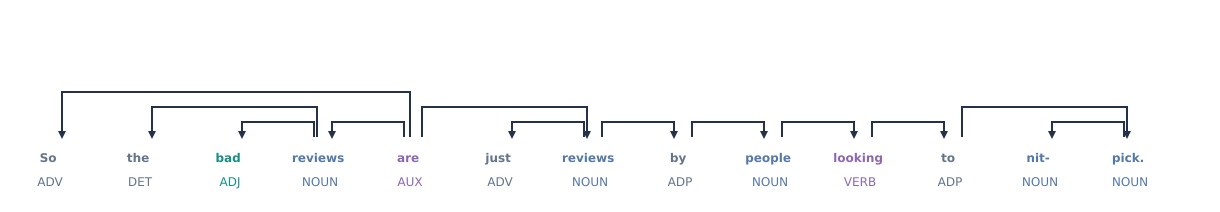

**Предложение 2.** The Amazon Tap is a perfect complement to our Amazon Echo.

Корень: **is** (AUX).

,Token,Relation,Head
0,Tap,nsubj,is
1,perfect,amod,complement


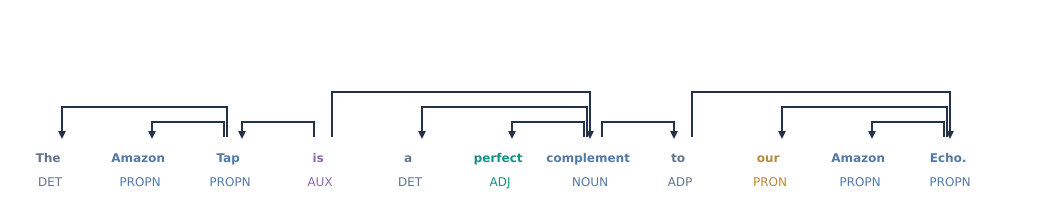

**Предложение 3.** But the Tap is meant to be mobile, and therefore I am happy it's not a Voice command device.

Корень: **meant** (VERB).

,Token,Relation,Head
0,Tap,nsubjpass,meant
1,mobile,acomp,be
2,I,nsubj,am
3,happy,acomp,am
4,it,nsubj,'s
5,not,neg,'s


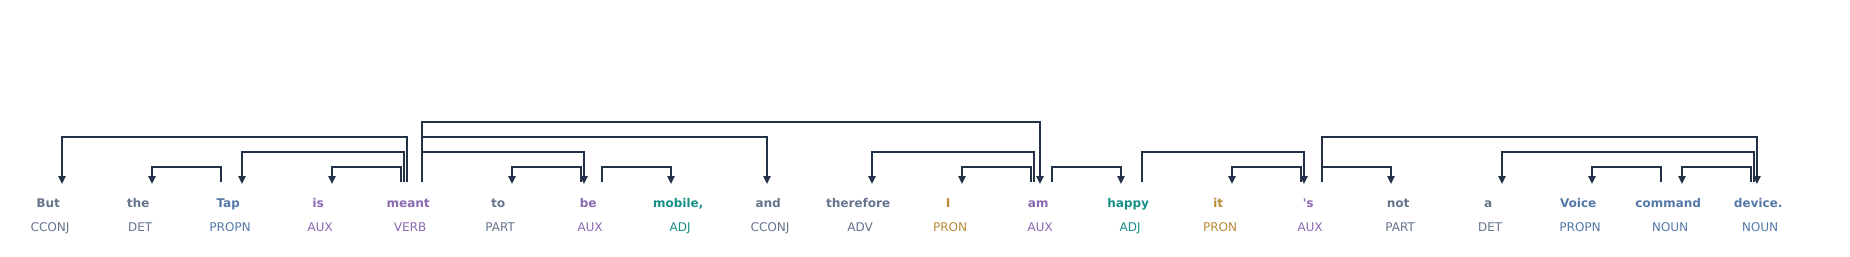

**Предложение 4.** I bought one for myself as well as my Mother.

Корень: **bought** (VERB).

,Token,Relation,Head
0,I,nsubj,bought
1,one,dobj,bought


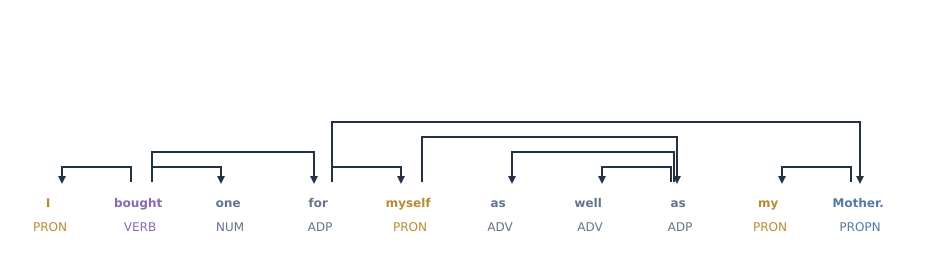

**Предложение 5.** It is certainly easy to use - just a tap away.

Корень: **is** (AUX).

,Token,Relation,Head
0,It,nsubj,is
1,easy,acomp,is


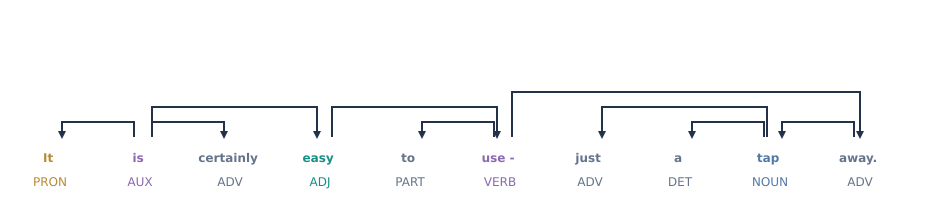

**Предложение 6.** I have also bought a cheap pouch to throw it into while transporting it.

Корень: **bought** (VERB).

,Token,Relation,Head
0,I,nsubj,bought
1,cheap,amod,pouch
2,pouch,dobj,bought
3,it,dobj,throw
4,it,dobj,transporting


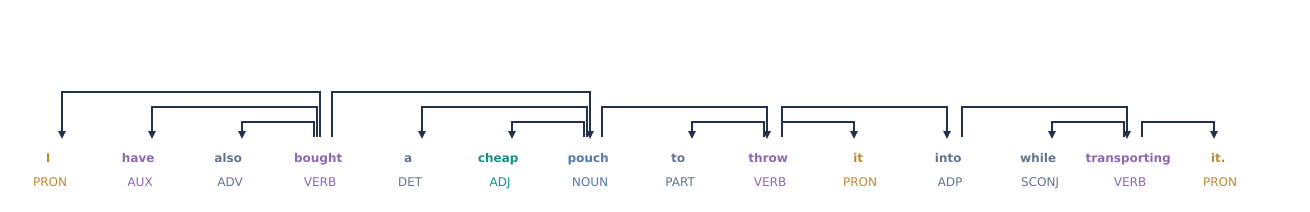

**Предложение 7.** The Amazon Tap is a great addition to my Smarthome system.

Корень: **is** (AUX).

,Token,Relation,Head
0,Tap,nsubj,is
1,great,amod,addition


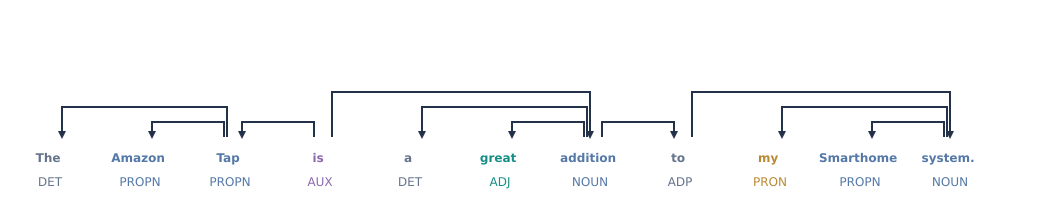

**Предложение 8.** Having a place to park the remote was such a fantastic feature.

Корень: **was** (AUX).

,Token,Relation,Head
0,place,dobj,Having
1,remote,dobj,park
2,fantastic,amod,feature


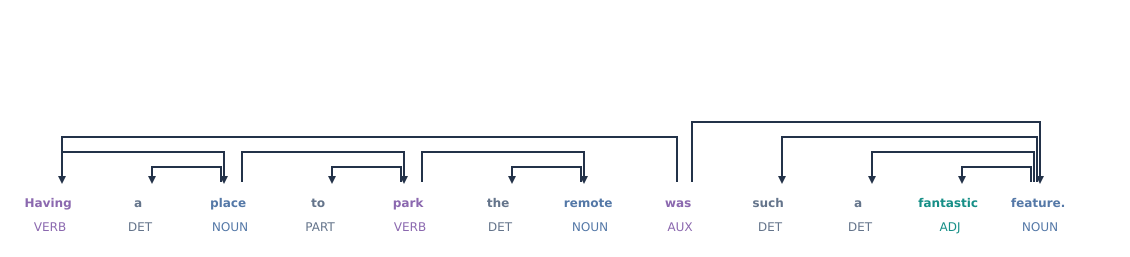

**Предложение 9.** This item will not disrupt the dynamic perspective or front facing cameras.

Корень: **disrupt** (VERB).

,Token,Relation,Head
0,item,nsubj,disrupt
1,not,neg,disrupt
2,dynamic,amod,perspective
3,perspective,dobj,disrupt
4,front,amod,cameras
5,facing,amod,cameras


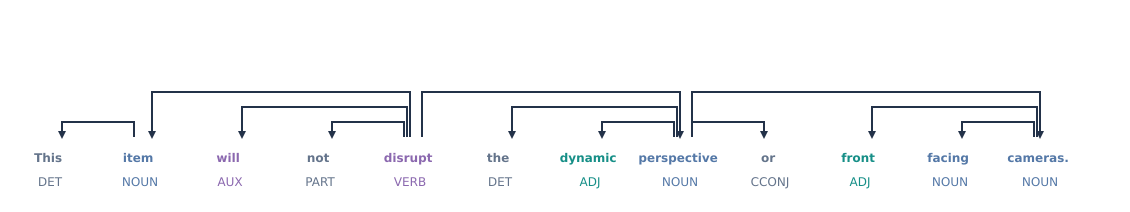

**Предложение 10.** It also makes it easy to transport in a purse, backpack, or messenger bag (or in luggage for traveling).

Корень: **makes** (VERB).

,Token,Relation,Head
0,It,nsubj,makes
1,it,nsubj,easy


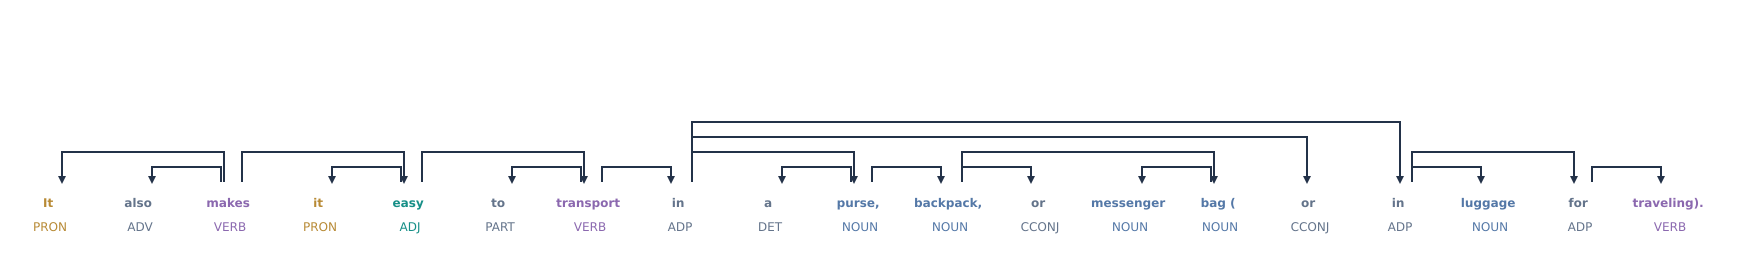

In [58]:
for number, row in enumerate(selected_sentences.itertuples(), 1):
    sent = docs[row.doc_id][row.start:row.end]
    display(Markdown(f"**Предложение {number}.** {sent.text}"))
    root = next(t for t in sent if t.dep_ == "ROOT")
    display(Markdown(f"Корень: **{root.text}** ({root.pos_})."))
    
    links = [{"Token": t.text, "Relation": t.dep_, "Head": t.head.text}
             for t in sent if t.dep_ in {"nsubj", "nsubjpass", "dobj", "amod", "acomp", "neg"}]
    
    display(pd.DataFrame(links))
    
    svg = displacy.render(sent, style="dep", jupyter=False, 
                          options={"compact": True, "distance": 90, "word_spacing": 25,"font_size": "13px", "color": INK, "bg": PAPER, "font": "DejaVu Sans"})
    
    tree = ET.fromstring(svg)
    pos_palette = {"NOUN": BLUE, "PROPN": BLUE, "ADJ": TEAL, "VERB": "#8B68AF", "AUX": "#8B68AF", "PRON": GOLD}
    
    for node in tree.iter():
        if node.attrib.get("class") == "displacy-token":
            spans = list(node)
            tag = next((s.text for s in spans if s.attrib.get("class") == "displacy-tag"), "")
            for span in spans:
                span.set("fill", pos_palette.get(tag, MUTED))
                if span.attrib.get("class") == "displacy-word":
                    span.set("font-weight", "600")
                    
    svg = ET.tostring(tree, encoding="unicode")
    display(SVG(svg))
    
    (Path(FIG_DIR) / f"dependency_{number:02d}.svg").write_text(svg, encoding="utf-8")

#### Анализ построенных деревьев

Построены **10 схем для предложений из разных отзывов**, длиной 10-20 непунктуационных токенов. Визуализация показывает предсказания модели, поэтому отдельная связь может оказаться ошибочной.

| № | Наблюдение по дереву | Что это даёт для анализа |
|---|---|---|
| 1 | `bad -> reviews` через `amod`, `reviews -> are` через `nsubj` | Формально извлекается `reviews - bad`, но это оценка других отзывов, а не устройства |
| 2 | `perfect -> complement`; `Tap` - подлежащее при `is` | Пара `complement - perfect` корректна локально, однако аспект товара выражен косвенно |
| 3 | Пассивное `Tap -> meant`, прилагательные `mobile` и `happy`, отрицание при `'s` | В одном предложении несколько предикатов. Нельзя приписывать все оценки одному существительному. |
| 4 | `I -> bought`, `one -> bought` как дополнение | Синтаксис выделяет действие покупки, но без контекста `one` не называет конкретный товар |
| 5 | `It -> is`, `easy -> is` | Оценка есть, явного именного аспекта нет. Простое правило аспектных пар её пропустит |
| 6 | `cheap -> pouch`, `pouch -> bought`; далее два `it` | Определение извлекается напрямую, местоимения требуют отдельного анализа. |
| 7 | `great -> addition`; `Tap -> is` | Общая положительная оценка товара передана через "отличное дополнение" |
| 8 | `fantastic -> feature`, `remote -> park` | В дереве разделены характеристика функции и действие с пультом |
| 9 | `not -> disrupt`, `dynamic -> perspective` | Отрицание относится к действию `disrupt`, а не к прилагательному `dynamic` |
| 10 | `makes` - корень, второе `it` связано с `easy` | Конструкция `makes it easy to …` сложнее обычного `noun is adjective`. Поверхностный поиск соседей здесь ненадёжен. |

**Итог:** дерево позволяет отличать определение, подлежащее, дополнение и отрицание. Но синтаксическая связь ещё не гарантирует, что полученная пара отражает аспект товара или тональность всего отзыва.

### Шаг 7. Алгоритм извлечения пар `аспект-оценка`
В отличие от поиска соседних слов, обходим связи дерева. Так можно извлечь оценку и в `bright screen`, и в `the screen is bright`, где между словами стоит глагол-связка.

Правила:
1. `amod`: прилагательное связано с NOUN/PROPN - берём существительное и прилагательное
2. `acomp`: прилагательное зависит от сказуемого - ищем у сказуемого подлежащее NOUN/PROPN
3. Однородные прилагательные через `conj` наследуют аспект, если у них нет своего подлежащего. Однородные именные подлежащие тоже учитываются.
4. Аспект лемматизируем; сохраняем непосредственно присоединённые именные `compound`, например `battery life`.
5. Отрицание у оценки или её сказуемого сохраняем как `not …`. Локальное отрицание не равно полноценному определению области действия отрицания.

Местоимения пока не считаем аспектами: `it is good` без контекста не говорит, что именно хорошее. Это ограничение разбираем на следующем шаге.

In [59]:
def nominal_group(token):
    parts = sorted([token] + [c for c in token.children if c.dep_ == "compound" and c.pos_ in {"NOUN", "PROPN"}], key=lambda t: t.i)
    return " ".join(t.lemma_.lower() for t in parts)

In [60]:
def extract_aspect_pairs(doc, doc_id=0):
    pairs, seen = [], set()
    for adj in doc:
        if adj.pos_ != "ADJ":
            continue
        base = adj
        
        while base.dep_ == "conj" and base.head.pos_ == "ADJ":
            if any(c.dep_ in {"nsubj", "nsubjpass"} for c in base.children):
                break
            base = base.head
        aspects, rule, predicate = [], None, None
        
        if base.dep_ == "amod" and base.head.pos_ in {"NOUN", "PROPN"}:
            aspects, rule = [base.head], "amod"
        elif base.dep_ == "acomp":
            predicate, rule = base.head, "acomp+nsubj"
            subjects = [c for c in predicate.children
                        if c.dep_ == "nsubj" and c.pos_ in {"NOUN", "PROPN"}]
            aspects = [n for s in subjects for n in [s] + list(s.conjuncts)
                       if n.pos_ in {"NOUN", "PROPN"}]
        if not aspects:
            continue
        
        own_neg = any(c.dep_ == "neg" for c in adj.children)
        pred_neg = adj.i == base.i and predicate is not None and any(c.dep_ == "neg" for c in predicate.children)
        negated = own_neg or pred_neg
        modifiers = " ".join(c.text for c in adj.children if c.dep_ == "advmod")
        
        for noun in aspects:
            key = (noun.i, adj.i)
            if key in seen:
                continue
            seen.add(key)
            pairs.append({"doc_id": doc_id, "aspect_id": noun.i, "opinion_id": adj.i,
                          "Aspect": nominal_group(noun), "Opinion": adj.lemma_.lower(),
                          "Negated": negated, "Evaluation": ("not " if negated else "") + adj.lemma_.lower(),
                          "Modifiers": modifiers, "Rule": rule + ("+conj" if base.i != adj.i else ""),
                          "Sentence": adj.sent.text})
    return pairs

Проверим правила на небольшом искусственном примере. Он нужен только для проверки алгоритма и не попадает в статистику корпуса.

In [61]:
demo = nlp("The screen is bright. The battery is not good. I like the small case.")
demo_pairs = extract_aspect_pairs(demo)

display(pd.DataFrame(demo_pairs))

assert {("screen", "bright"), ("battery", "not good"), ("case", "small")} <= {(p["Aspect"], p["Evaluation"]) for p in demo_pairs}

,doc_id,aspect_id,opinion_id,Aspect,Opinion,Negated,Evaluation,Modifiers,Rule,Sentence
0,0,1,3,screen,bright,False,bright,,acomp+nsubj,The screen is bright.
1,0,6,9,battery,good,True,not good,,acomp+nsubj,The battery is not good.
2,0,15,14,case,small,False,small,,amod,I like the small case.


Теперь применим функцию ко всем отзывам. Частоту считаем по вхождениям, а рядом показываем число разных отзывов: один длинный текст может повторять одну и ту же пару несколько раз.

In [62]:
pair_rows = [row for doc_id, doc in enumerate(docs) for row in extract_aspect_pairs(doc, doc_id)]

pairs_df = pd.DataFrame(pair_rows)
pairs_df["Sentiment"] = pairs_df["doc_id"].map(df["Sentiment"].astype(str))

pair_counts = (pairs_df.groupby(["Aspect", "Evaluation"]).agg(Count=("doc_id", "size"), Reviews=("doc_id", "nunique"))
               .reset_index().sort_values(["Count", "Reviews", "Aspect", "Evaluation"], ascending=[False, False, True, True]))
top20 = pair_counts.head(20).copy()
display(top20)

pairs_df.to_csv(Path(DATA_DIR) / "aspect_opinion_pairs.csv", index=False)
top20.to_csv(Path(DATA_DIR) / "top20_pairs.csv", index=False)

print("Всего вхождений пар:", len(pairs_df))
print("Уникальных пар:", len(pair_counts))
print("Отзывов хотя бы с одной парой:", pairs_df.doc_id.nunique())

,Aspect,Evaluation,Count,Reviews
3377,year,last,65,20
2276,quality,sound,58,56
2695,sound,great,35,35
2694,sound,good,26,26
3020,time,first,23,18
2210,product,great,22,22
2750,speaker,portable,21,19
2736,speaker,great,20,17
1571,kindle,new,18,17
3026,time,long,17,17


Всего вхождений пар: 5289
Уникальных пар: 3386
Отзывов хотя бы с одной парой: 754


In [63]:
# ручная интерпретация типов пар для визуализации
plot_pairs = top20.copy().reset_index(drop=True)
def pair_kind(row):
    if row.Aspect == "quality" and row.Evaluation == "sound":
        return "Подозрительная пара"
    if row.Evaluation in {"great", "good"}:
        return "Оценочная лексика"
    return "Описание / контекст"

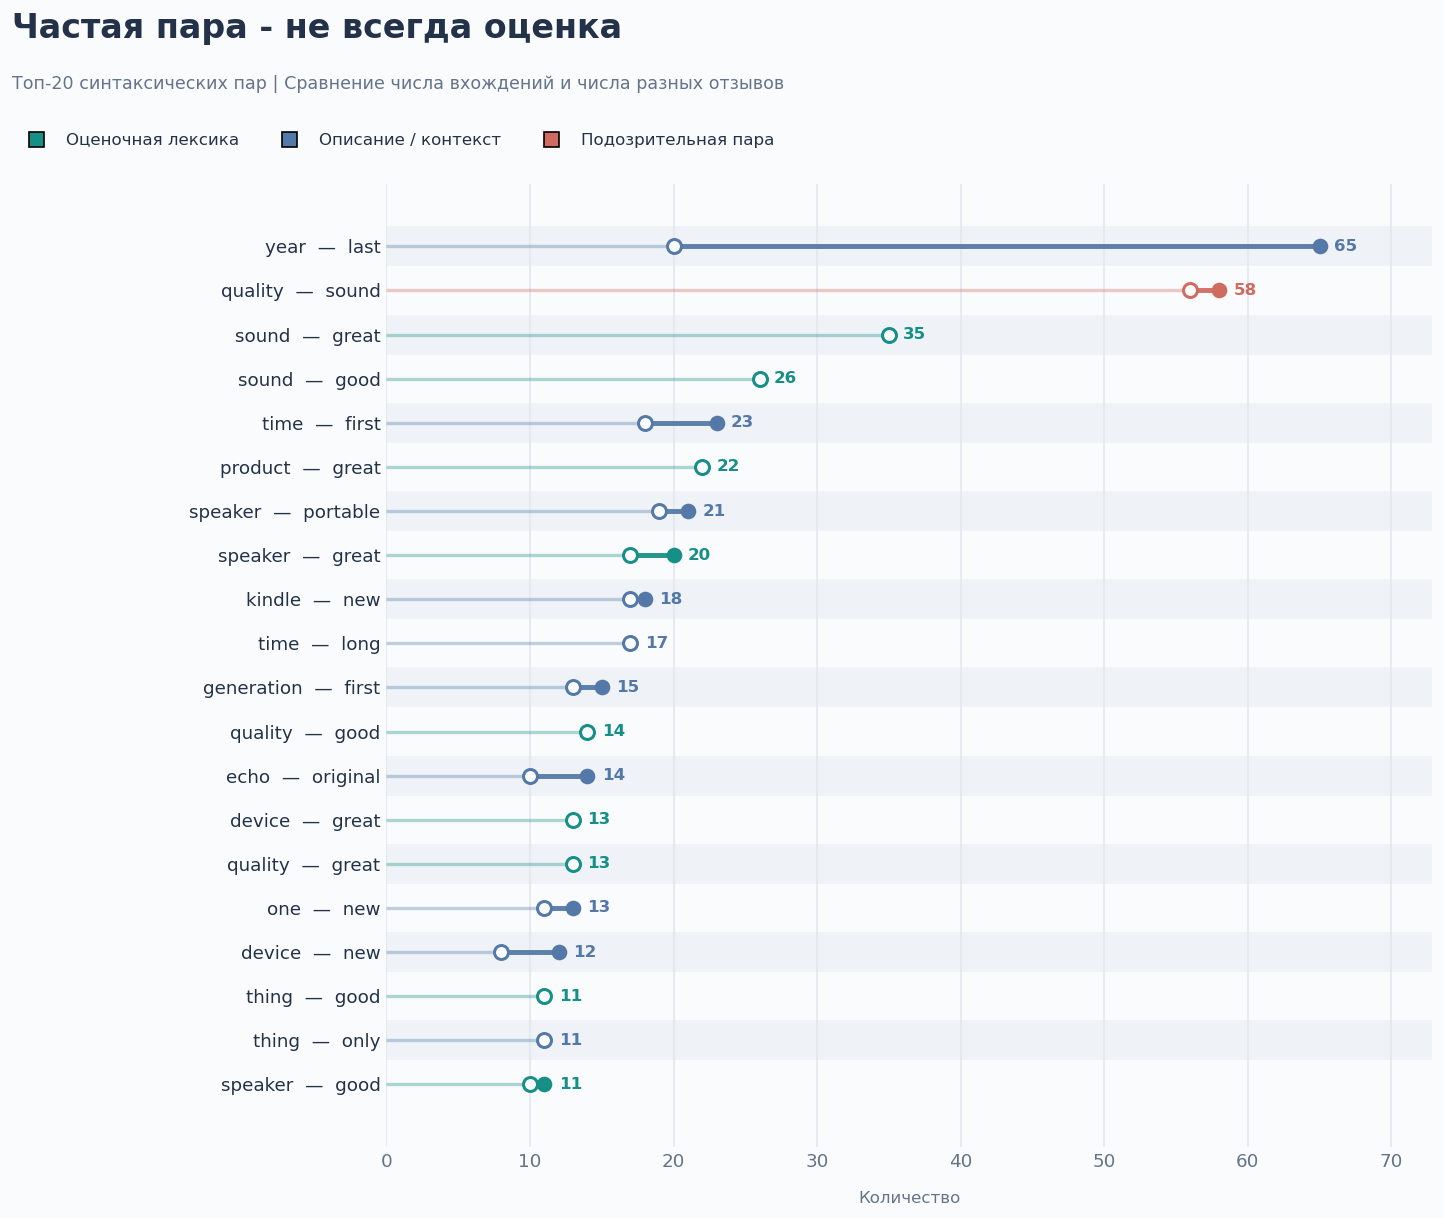

In [64]:
plot_pairs["Kind"] = plot_pairs.apply(pair_kind, axis=1)
pair_palette={"Оценочная лексика":TEAL,"Описание / контекст":BLUE,"Подозрительная пара":CORAL}
fig,ax=plt.subplots(figsize=(13,11))
fig.subplots_adjust(left=0.27,right=0.94,top=0.83,bottom=0.10)
chart_header(fig,"Частая пара - не всегда оценка", "Топ-20 синтаксических пар | Сравнение числа вхождений и числа разных отзывов")

for i,r in enumerate(plot_pairs.itertuples()):
    color=pair_palette[r.Kind]
    ax.axhspan(i-0.43,i+0.43,color="#EFF3F7" if i%2==0 else PAPER,zorder=0)
    ax.hlines(i,0,r.Count,color=color,linewidth=2,alpha=0.35)
    ax.hlines(i,r.Reviews,r.Count,color=color,linewidth=3,alpha=0.9)
    ax.scatter(r.Count,i,s=70,color=color,zorder=4)
    ax.scatter(r.Reviews,i,s=70,facecolors=PAPER,edgecolors=color,linewidths=1.8,zorder=5)
    ax.text(r.Count+1.0,i,str(r.Count),va="center",color=color,weight="bold",fontsize=10)
    
ax.set_yticks(range(len(plot_pairs)),plot_pairs.Aspect+"  —  "+plot_pairs.Evaluation)
ax.invert_yaxis()
ax.set_xlim(0,plot_pairs.Count.max()*1.12)
ax.set_xlabel("Количество",labelpad=12)
ax.xaxis.grid(True,color=GRID)
ax.set_axisbelow(True)
ax.tick_params(length=0)

legend=[Line2D([0],[0],marker="s",color="none",markerfacecolor=v,markersize=9,label=k) for k,v in pair_palette.items()]
fig.legend(handles=legend,loc="upper left",bbox_to_anchor=(0.025,0.88),frameon=False,ncol=3,fontsize=10)

Посмотрим контекст каждой пары из топ-20. Само наличие прилагательного ещё не означает эмоциональную оценку: `new`, `small` и `other` могут описывать свойство или различие объектов. Сохраняем отрицание и исходное предложение, чтобы не потерять смысл.

In [65]:
top_context = top20.merge(
    pairs_df.drop_duplicates(["Aspect", "Evaluation"])[["Aspect", "Evaluation", "Sentence", "Rule"]],
    on=["Aspect", "Evaluation"], how="left", validate="one_to_one")

display(top_context)
group_sizes = df["Sentiment"].value_counts()

pair_presence = pairs_df.drop_duplicates(["doc_id", "Aspect", "Evaluation"])
pair_by_group = pd.crosstab([pair_presence.Aspect, pair_presence.Evaluation], pair_presence.Sentiment)
pair_by_group = pair_by_group.div(group_sizes, axis="columns") * 100

display(pair_by_group.reindex(pd.MultiIndex.from_frame(top20[["Aspect", "Evaluation"]])).fillna(0).round(2))

,Aspect,Evaluation,Count,Reviews,Sentence,Rule
0,year,last,65,20,"For comparison sake, I will use last year's Kindle Fire HD 8.9 and also the Fire HDX 7 as benchmarksSpeed (9/10):The same chipset is used on the Kindle Fire HDX 8.9 as it is in the Kindle Fire 7 As I mentioned in the 7 review, this is leaps and bounds faster than last year Kindle HD.",amod
1,quality,sound,58,56,The minimal coverage is needed not to hurt the sound quality coming from the speaker...,amod
2,sound,great,35,35,"Great device it's zippy, has an AWESOME display, great sound for a tablet (rivals/bests any portable device I currently own, including laptops) has incredible ease of use and I'm basically all-in on the Amazon ecosystem.",amod
3,sound,good,26,26,Good sound: The speakers on the Show sound much better than the original echo.,amod
4,time,first,23,18,"I'm a first-time Kindle owner, so I have nothing to compare the latest Kindle to.",amod
5,product,great,22,22,(But I will say this: They've taken a great product and made it even better.),amod
6,speaker,portable,21,19,I test portable speakers all the time and Id say the Amazon Tap is as good as or better than the speakers in its price range.,amod
7,speaker,great,20,17,"But all in all this is a great speaker, that can do everything any Bluetooth speaker on the market can do plus a little bit extra.",amod
8,kindle,new,18,17,"With this new kindle I don't even notice, I am immediately immersed.",amod
9,time,long,17,17,"The high resolution screen does provide a crisp text which is pleasing to the eye, but battery life is reduced from 8 weeks of the original Paperwhite to 6 weeks - but still a very long time.",amod


Sentiment              negative  neutral  positive
Aspect     Evaluation                             
year       last            0.00     1.43      2.48
quality    sound           0.00     4.29      6.93
sound      great           0.00     5.71      4.05
           good            0.00     4.29      3.01
time       first           2.78     0.00      2.09
product    great           1.39     1.43      2.61
speaker    portable        0.00     1.43      2.35
           great           0.00     1.43      2.09
kindle     new             4.17     1.43      1.70
time       long            0.00     1.43      2.09
generation first           0.00     0.00      1.70
quality    good            1.39     1.43      1.57
echo       original        0.00     2.86      1.05
device     great           0.00     5.71      1.18
quality    great           0.00     0.00      1.70
one        new             5.56     1.43      0.78
device     new             0.00     1.43      0.92
thing      good            1.39     2.86      1.05
           only            0.00     1.43      1.31
speaker    good            0.00     0.00      1.31

#### Анализ извлечённых паттернов

Алгоритм нашёл **5 289 вхождений**, **3 386 уникальных пар** и хотя бы одну пару в **754 из 907 отзывов (83.13%)**. Это покрытие корпуса правилами, а не precision или recall. По прямому `amod` извлечено 4 507 вхождений, по `acomp+nsubj` - 690, ещё 92 - через однородные прилагательные. В 73 вхождениях сохранено локальное отрицание.

**Насколько топ-20 отражает предметную область?** Пары `sound-great` (35), `sound-good` (26), `speaker-great` (20) и `speaker-good` (11) действительно описывают звук и динамики. `product-great` (22), `device-great` (13) и `quality-great` (13) показывают общую положительную оценку, но менее конкретны: по ним трудно понять, что именно понравилось.

Часть пар описательна: `speaker-portable`, `kindle-new`, `echo-original`, `generation-first`. Они полезны для характеристики предметной области, но не являются прямыми индикаторами положительной тональности. `one-new` и `thing-good` слишком неопределённы без контекста.

**Самая частая пара `year-last` (65 вхождений в 20 отзывах) вообще не является оценкой устройства.** Это временная конструкция. Большая разница между числом вхождений и документов показывает, почему рядом с частотой нужно считать документную частоту. Близкие, но не идентичные варианты отзывов также могут остаться после удаления только точных дубликатов.

**Пара `quality-sound` (58) характерная ошибка.** В проверенных предложениях `sound quality` означает «качество звука»: `sound` выступает именным модификатором. Теггер иногда выбирает ADJ, и правило ошибочно принимает его за оценку. Сам по себе высокий ранг не делает паттерн правильным; ошибка POS распространяется на следующий этап.

Группировка по рейтингу тоже требует осторожности. `product-great` встречается даже в отрицательной группе (1.39% отзывов): автор может хвалить отдельную сторону и оставаться недовольным в целом. `sound-great` встречается в 5.71% нейтральных и 4.05% положительных отзывов. Редкие классы малы, поэтому несколько документов заметно меняют проценты.

**Вывод:** правила выделяют полезные локальные характеристики, но смешивают оценки, нейтральные свойства и ошибки разметки. Для более точной аспектной аналитики нужны фильтр предметных аспектов, обработка отрицания и кореференции, а затем ручная проверка случайной выборки. Токсичность здесь не оценивалась: у датасета нет соответствующих меток, а наличие отрицательного рейтинга не означает токсичность.

### Шаг 8. Разрешение анафоры на основе правил
Анафора - ссылка на ранее упомянутый объект: `I bought a tablet. It works well.` Здесь `It` можно заменить на `tablet`. В корпусе встречаются `he`, `she`, `it`, `they`, объектные и притяжательные формы, а также указательные `this/that/these/those` в роли местоимений.

Алгоритм ищет существительное в текущем и двух предыдущих предложениях **того же отзыва**. Сначала проверяет согласование по `Number` и `Gender`. У английских существительных род часто не указан: неизвестное значение не считаем противоречием. Для человеческих обозначений добавляем небольшой явный словарь (`mother`, `father`, `child` и т. д.).

Далее ранжируем кандидатов по синтаксическому расстоянию. Внутри предложения это число рёбер кратчайшего пути по дереву. Между предложениями добавляем условную связь между корнями: сумма глубин + 2 за каждую границу. Поэтому межфразовое расстояние - наша эвристика, а не готовая межфразовая связь spaCy.

Функция стоимости:
`cost = syntax_distance + 2 * sentence_gap + 0.03 * token_gap - 0.5 * is_subject`.

Чем меньше стоимость, тем лучше кандидат. Если разница между двумя лучшими кандидатами меньше 1, оставляем местоимение без замены. Числа в формуле заданы вручную и не обучались. Отдельно пропускаем очевидные безличные `it` (погода, экстрапозиция) и относительное `that`.

Замены делаем по символьным позициям справа налево. Это сохраняет исходную пунктуацию и не путает разные вхождения `it`.

In [66]:
PRONOUN_FORMS = {"he", "him", "his", "she", "her", "hers", "it", "its",
                 "they", "them", "their", "theirs", "this", "that", "these", "those"}
MALE = {"father", "dad", "husband", "son", "boy", "brother", "man", "grandfather"}
FEMALE = {"mother", "mom", "wife", "daughter", "girl", "sister", "woman", "grandmother"}
HUMAN = MALE | FEMALE | {"child", "kid", "friend", "parent", "customer", "person", "user", "grandchild"}

In [67]:
def gender_of(token):
    features = token.morph.get("Gender")
    if features:
        return features[0]
    lemma = token.lemma_.lower()
    return "Masc" if lemma in MALE else "Fem" if lemma in FEMALE else None

In [68]:
def number_of(token):
    features = token.morph.get("Number")
    if features:
        return features[0]
    if token.lower_ in {"they", "them", "their", "theirs", "these", "those"}:
        return "Plur"
    if token.lower_ in PRONOUN_FORMS:
        return "Sing"
    return None

In [69]:
def compatible(pronoun, noun):
    pn, nn = number_of(pronoun), number_of(noun)
    pg, ng = gender_of(pronoun), gender_of(noun)
    
    if pn and nn and pn != nn:
        return False
    
    if pg and ng and pg != ng:
        return False
    
    if pronoun.lower_ in {"he", "him", "his", "she", "her", "hers"}:
        if noun.lemma_.lower() not in HUMAN and ng not in {"Masc", "Fem"}:
            return False
    
    if pronoun.lower_ in {"it", "its", "this", "that"} and noun.lemma_.lower() in HUMAN:
        return False
    
    return True

In [70]:
def syntax_distance(a, b):
    # Путь через ближайшего общего предка, без зависимости от направления ребер
    a_chain = [a] + list(a.ancestors)
    b_chain = [b] + list(b.ancestors)
    a_depths = {t.i: i for i, t in enumerate(a_chain)}
    
    for depth, token in enumerate(b_chain):
        if token.i in a_depths:
            return depth + a_depths[token.i]
            
    return None  # разные деревья предложений

In [71]:
def is_nonreferential(token):
    if token.dep_ == "expl" or "Rel" in token.morph.get("PronType"):
        return True
    
    if token.lower_ != "it":
        return False
    
    head = token.head
    
    if head.lemma_.lower() in {"rain", "snow"}:
        return True
    
    pred_adj = [c for c in head.children if c.dep_ in {"acomp", "attr"}]
    
    return head.lemma_ == "be" and any(
        c.dep_ in {"ccomp", "xcomp", "csubj"}
        for governor in [head] + pred_adj for c in governor.children
    )

In [72]:
def replacement_form(pronoun, noun):
    # Берём исходную форму существительного, а не лемму - сохраняем число
    text = noun.text
    
    if pronoun.morph.get("Poss") == ["Yes"] or pronoun.lower_ in {"his", "hers", "its", "their", "theirs"}:
        text += "'" if number_of(noun) == "Plur" and text.lower().endswith("s") else "'s"
    
    if pronoun.i == pronoun.sent.start:
        text = text[0].upper() + text[1:]
    
    return text

In [73]:
def resolve_anaphora(doc, doc_id=0, window=2, min_margin=1.0):
    sentences = list(doc.sents)
    sentence_of = {t.i: i for i, sent in enumerate(sentences) for t in sent}
    decisions = []
    
    for pronoun in doc:
        if pronoun.lower_ not in PRONOUN_FORMS or pronoun.pos_ not in {"PRON", "DET"}:
            continue
       
        # this tablet / that device - определители, а не самостоятельные ссылки
        if pronoun.dep_ == "det":
            continue
        sid = sentence_of[pronoun.i]
        row = {"doc_id": doc_id, "sent_id": sid, "pronoun_id": pronoun.i,
               "Pronoun": pronoun.text, "Number": number_of(pronoun), "Gender": gender_of(pronoun),
               "Antecedent": "", "antecedent_id": -1, "Cost": np.nan, "Margin": np.nan,
               "Replacement": "", "Status": "no_candidate", "Sentence": pronoun.sent.text}
        
        if is_nonreferential(pronoun):
            row["Status"] = "nonreferential_or_relative"
            decisions.append(row)
            continue
        
        ranked = []
        
        for noun in doc[max(0, sentences[max(0, sid-window)].start):pronoun.i]:
            if noun.pos_ not in {"NOUN", "PROPN"} or not compatible(pronoun, noun):
                continue
            if noun.dep_ == "compound":
                continue
            
            # Запрещаем локальную замену объектного местоимения подлежащим того же глагола
            # для такой кореференции обычно нужна возвратная форма himself/itself
            if pronoun.dep_ in {"dobj", "dative"} and noun.dep_ in {"nsubj", "nsubjpass"} and noun.head.i == pronoun.head.i:
                continue
            gap = sid - sentence_of[noun.i]
            distance = syntax_distance(pronoun, noun)
            
            if distance is None:
                distance = len(list(pronoun.ancestors)) + len(list(noun.ancestors)) + 2 * gap
            cost = distance + 2 * gap + 0.03 * (pronoun.i - noun.i) - 0.5 * (noun.dep_ in {"nsubj", "nsubjpass"})
            ranked.append((cost, noun.i, noun))
        
        ranked.sort(key=lambda x: (x[0], -x[1]))
        
        if ranked:
            cost, _, best = ranked[0]
            margin = ranked[1][0] - cost if len(ranked) > 1 else float("inf")
            row.update(Antecedent=best.text, antecedent_id=best.i, Cost=cost, Margin=margin)
            if margin >= min_margin:
                row.update(Status="resolved", Replacement=replacement_form(pronoun, best))
            else:
                row["Status"] = "ambiguous"
        
        decisions.append(row)

    # Решения вычисляются по исходному дереву, замены не создают цепочку новых догадок.
    changed = []
    for sid, sent in enumerate(sentences):
        edits = [r for r in decisions if r["sent_id"] == sid and r["Status"] == "resolved"]
        if not edits:
            continue
        text = sent.text
        for r in sorted(edits, key=lambda x: x["pronoun_id"], reverse=True):
            token = doc[r["pronoun_id"]]
            start = token.idx - sent.start_char
            text = text[:start] + r["Replacement"] + text[start+len(token.text):]
        context = doc[sentences[max(0, sid-window)].start:sent.end].text
        changed.append({"doc_id": doc_id, "sent_id": sid, "Context": context,
                        "Original": sent.text, "Changed": text, "Replacements": len(edits)})
    
    
    return decisions, changed

Проверим согласование и отказ от безличного `it` на контролируемых примерах

In [74]:
test_doc = nlp("I bought a tablet. It works well. My mother arrived. She smiled. It is raining.")
test_decisions, test_changed = resolve_anaphora(test_doc)

display(pd.DataFrame(test_changed)[["Original", "Changed"]])

assert any(r["Pronoun"] == "It" and r["Antecedent"] == "tablet" and r["Status"] == "resolved" for r in test_decisions)
assert any(r["Pronoun"] == "She" and r["Antecedent"] == "mother" and r["Status"] == "resolved" for r in test_decisions)
assert test_decisions[-1]["Status"] == "nonreferential_or_relative"

,Original,Changed
0,It works well.,Tablet works well.
1,She smiled.,Mother smiled.


Применим алгоритм к корпусу. 

Таблица статусов показывает, сколько ссылок правило заменило, сколько оставило неоднозначными и где не нашло кандидата.

Это **покрытие правил**, а не точность. Успешно выполненная замена может быть смысловой ошибкой.

In [75]:
decision_rows, changed_rows = [], []

for doc_id, doc in enumerate(docs):
    decisions, changes = resolve_anaphora(doc, doc_id)
    decision_rows.extend(decisions)
    changed_rows.extend(changes)

anaphora_df = pd.DataFrame(decision_rows)
changes_df = pd.DataFrame(changed_rows)
display(anaphora_df["Status"].value_counts().rename_axis("Status").to_frame("Count"))

anaphora_df.to_csv(Path(DATA_DIR) / "anaphora_decisions.csv", index=False)
changes_df.to_csv(Path(DATA_DIR) / "anaphora_before_after.csv", index=False)

,Count
Status,
resolved,2589
ambiguous,862
no_candidate,554
nonreferential_or_relative,503


Визуально сравним исходы алгоритма анафоры. Подписи показывают и количество, и долю всех рассмотренных вхождений. 

`Выполнена замена` означает действие алгоритма, а не подтверждённую правильность

Text(0.5, 0, 'Доля всех рассмотренных вхождений')

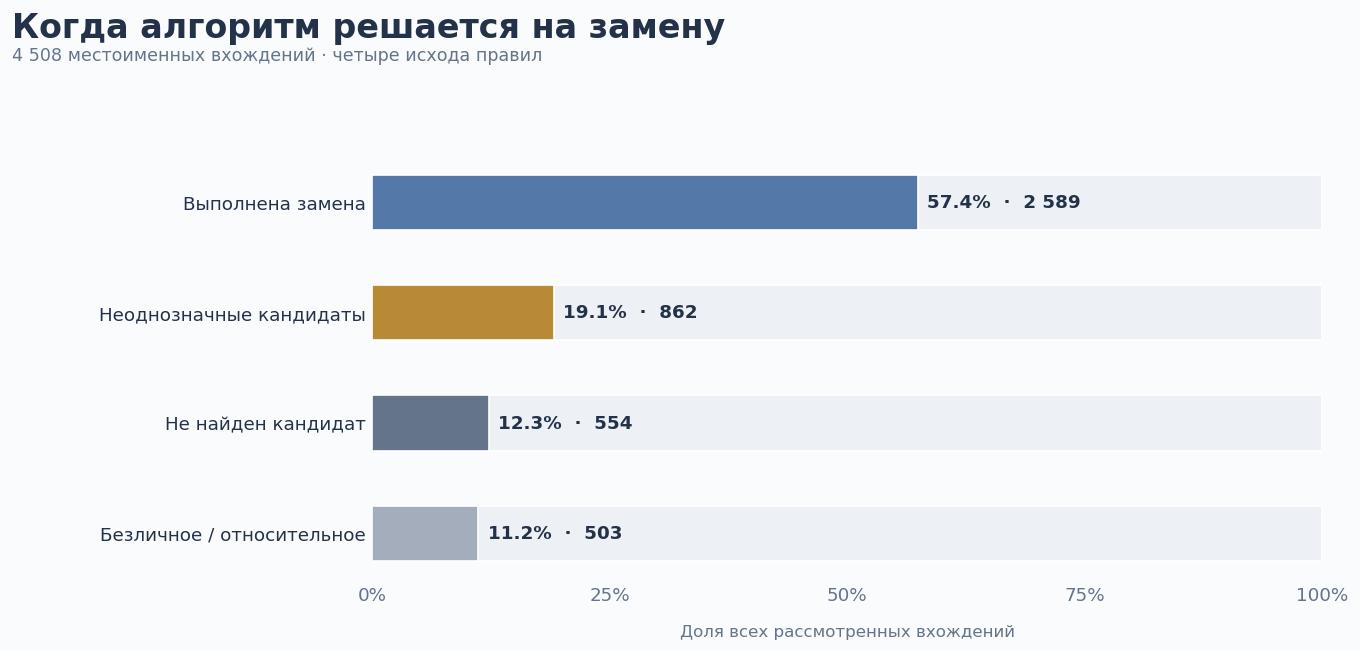

In [76]:
status_order=["resolved","ambiguous","no_candidate","nonreferential_or_relative"]
status_labels=["Выполнена замена","Неоднозначные кандидаты","Не найден кандидат","Безличное / относительное"]

counts=anaphora_df.Status.value_counts().reindex(status_order,fill_value=0)

fig,ax=plt.subplots(figsize=(12,6))
fig.subplots_adjust(left=0.28,right=0.94,top=0.76,bottom=0.17)
chart_header(fig,"Когда алгоритм решается на замену", f"{len(anaphora_df):,} местоименных вхождений · четыре исхода правил".replace(","," "))
shares=counts/counts.sum()*100

for i,(count,share,color) in enumerate(zip(counts,shares,[BLUE,GOLD,MUTED,"#A3ADBB"])):
    ax.barh(i,100,height=0.5,color="#EDF1F5")
    ax.barh(i,share,height=0.5,color=color)
    ax.text(share+1,i,f"{share:.1f}%  ·  {count:,}".replace(","," "),va="center",weight="bold",color=INK)

ax.set_yticks(range(4),status_labels)
ax.invert_yaxis()
ax.set_xlim(0,100)
ax.set_xticks([0,25,50,75,100],["0%","25%","50%","75%","100%"])
ax.tick_params(length=0)
ax.set_xlabel("Доля всех рассмотренных вхождений",labelpad=12)

#### Анализ разрешения анафоры

Проверено **4 508 вхождений выбранных местоименных форм**. Правила выполнили **2 589 замен (57.43%)**, для 862 случаев оставили неоднозначность, в 554 не нашли подходящего кандидата, ещё 503 отнесли к безличным/относительным конструкциям по заданным эвристикам. Последняя категория тоже предсказывается правилами и может содержать ошибки.

Это **частота принятых решений, а не точность 57.43%**. Без независимой разметки нельзя сказать, сколько всех замен правильные. Ниже сопоставлены конкретные удачные и неудачные решения; подборка иллюстративная, не случайная.

Посмотрим восемь исходных и изменённых предложений. Для каждого приведён контекст, затем ручной комментарий. Корректность оцениваем **для конкретной ссылки**: в одном предложении одна замена может быть правильной, а другая — ошибочной.

In [77]:
audit_specs = [
    ("They only appear on screen when the screen saver is on, and are not at all distracting.",
     "They -> adverts: правильная связь. Совпадают множественное число и контекст обсуждения рекламы."),
    ("I can hold it in one hand easily.",
     "it -> Kindle: правильная ссылка на устройство в предыдущем предложении."),
    ("I already had an original Kindle Paperwhite and loved it.",
     "it -> Paperwhite: верно восстановлена ссылка на объект в том же предложении."),
    ("Some people also buy a cover, but I think this is not really needed.",
     "this -> cover: разумное именное прочтение, но this может относиться и ко всей покупке чехла; пример неоднозначен."),
    ("He is a gamer and he was very happy with it.",
     "He/he -> son: правильные ссылки с учётом рода. it -> gamer: ошибка, речь об устройстве. Словарь людей не включает gamer, поэтому согласования оказалось недостаточно."),
    ("My husband still has his Paperwhite, so I was able to compare them side by side.",
     "his -> husband's: верно найден владелец. them осталось без замены: правило не объединяет два отдельных упоминания устройств в множественную группу."),
    ("Haven't experienced that with the Paperwhite yet.",
     "that -> Fire: ошибка. Местоимение отсылает к описанной ситуации усталости глаз, а не к названию устройства."),
    ("Amazon states it can hold thousands of books.",
     "it -> Amazon: ошибка. По предыдущему контексту имеется в виду Kindle, близкий синтаксически кандидат неверен по смыслу.")
]

In [78]:
audit_rows = []

for number, (original, comment) in enumerate(audit_specs, 1):
    matches = changes_df[changes_df["Original"].eq(original)]

    if matches.empty:
        raise ValueError(f"Не найден пример анафоры: {original}")
        
    row = matches.iloc[0]
    audit_rows.append({"Original": row.Original, "Changed": row.Changed, "Analysis": comment})
    
    display(Markdown(f"**Пример {number}.** Контекст: {row.Context}"))
    display(pd.DataFrame({"Исходное предложение": [row.Original], "После замены": [row.Changed]}))
    display(Markdown(comment))
    
pd.DataFrame(audit_rows).to_csv(Path(DATA_DIR) / "anaphora_manual_analysis.csv", index=False)

**Пример 1.** Контекст: What other options do I have----------------------------------Having decided upon the model (Kindle, Paperwhite, Voyage or Fire), the next decision is around:-* Special Offers - ie. adverts* 3G or WIFI connectionPersonally I have no issue with adverts on a Kindle. They only appear on screen when the screen saver is on, and are not at all distracting.

,Исходное предложение,После замены
0,"They only appear on screen when the screen saver is on, and are not at all distracting.","Adverts only appear on screen when the screen saver is on, and are not at all distracting."


They -> adverts: правильная связь. Совпадают множественное число и контекст обсуждения рекламы.

**Пример 2.** Контекст: Hardcovers are sometimes a bit heavy, and paperbacks don't always lie open easily. The Kindle is incredibly light and thin. I can hold it in one hand easily.

,Исходное предложение,После замены
0,I can hold it in one hand easily.,I can hold Kindle in one hand easily.


...

,Исходное предложение,После замены
0,Haven't experienced that with the Paperwhite yet.,Haven't experienced Fire with the Paperwhite yet.


that -> Fire: ошибка. Местоимение отсылает к описанной ситуации усталости глаз, а не к названию устройства.

**Пример 8.** Контекст: The general consensus appears to be that its to be expected once one has that many books downloaded onto a Kindle, it will begin to behave in a flakey manner. This drives me mad. Amazon states it can hold thousands of books.

,Исходное предложение,После замены
0,Amazon states it can hold thousands of books.,Amazon states Amazon can hold thousands of books.


it -> Amazon: ошибка. По предыдущему контексту имеется в виду Kindle, близкий синтаксически кандидат неверен по смыслу.

#### Выводы по анафоре

Число и род отбрасывают часть невозможных кандидатов, а расстояние по дереву помогает на локальных связях. Но слово может быть близко синтаксически и при этом не подходить по смыслу. Особенно сложны ссылки на целую ситуацию (`that`), несколько объектов одновременно (`them`) и длинные шумные предложения.

Алгоритм заменяет местоимение исходной формой существительного. Это делает связь явной, но не всегда даёт естественный английский текст. Так для `cover` иногда нужен артикль, для `son` притяжательное определение, а название `Kindle Paperwhite` сокращается до опорного `Paperwhite`. Восстановление связи и грамматически гладкое переписывание это разные задачи. Полноценная генерация именной группы здесь не реализована.

Отказ при неоднозначности полезен, но не гарантирует правильность остальных замен. Ошибочный кандидат тоже может уверенно выиграть по эвристической стоимости. Следующий шаг для оценки качества - вручную разметить случайные местоименные упоминания, отдельно посчитать точность выполненных замен и долю найденных корректных ссылок.

### Шаг 9. Проверки результатов
Проверим, что идентификаторы токенов не повторяются, доли нормированы, построены 10 схем и показаны 20 пар. Эти проверки контролируют воспроизводимость расчётов, лингвистическую корректность оцениваем отдельно по контексту.

In [79]:
assert len(docs) == len(df)
assert not tokens_df.duplicated(["doc_id", "token_id"]).any()
assert not content_tokens["POS"].eq("PUNCT").any()
assert np.isclose(pos_counts["Percent"].sum(), 100)
assert np.allclose(pos_by_sentiment.sum(axis=1), 100)
assert len(selected_sentences) == 10
assert len(top20) == 20
assert error_analysis["Is_error"].sum() >= 5, "На другой версии модели перепроверить примеры ошибок"
assert all((Path(FIG_DIR) / f"dependency_{i:02d}.svg").exists() for i in range(1, 11))

pos_counts.to_csv(Path(DATA_DIR) / "pos_distribution.csv", index=False)
pos_by_sentiment.to_csv(Path(DATA_DIR) / "pos_by_sentiment.csv")

print("Проверки пройдены: 10 деревьев, топ-20 пар, не менее 5 разобранных ошибок.")

Проверки пройдены: 10 деревьев, топ-20 пар, не менее 5 разобранных ошибок.


#### Общие выводы

1. **Выполнена разметка корпуса:** 907 отзывов, 110 373 токена без пробелов. Существительные, глаголы и местоимения составляют основную часть распределения. Морфологические признаки сохранены и используются в дальнейших правилах.

2. **Проведено сравнение рейтинговых групп.** В отрицательных отзывах выше токенная доля глаголов и наречий. Прилагательные требуют более осторожной интерпретации, потому что ранжирование групп меняется при усреднении по документам. Рейтинг, длина текста и содержание связаны, но причинность и статистическая значимость здесь не устанавливались.

3. **Разобраны семь ошибок POS-теггера.** CAPS и техническая лексика приводят к неверным категориям, а потерянное прилагательное может лишить нас оценочной пары. В четырёх из пяти CAPS-примеров изменение регистра исправило тег, для заголовка `KNOW WHAT YOU ARE BUYING` этого недостаточно.

4. **Построены 10 деревьев зависимостей.** Схемы показывают, как различаются определения, подлежащие, дополнения и отрицания. На их основе реализован обход дерева для извлечения смысловых пар.

5. **Получен топ-20 из 3 386 уникальных пар.** Алгоритм извлекает полезные характеристики звука, динамиков и устройств, но также нейтральные конструкции и ложные пары. `year-last` и `quality-sound` показывают, почему частотный список обязательно нужно проверять по контекстам.

6. **Реализована анафора на правилах:** морфологическое согласование, синтаксическое расстояние, ограниченное окно контекста и отказ при близких кандидатах. На простых ссылках правила работают, но ошибаются на ссылках на ситуации, конкурирующих существительных и шумной разметке. Для надёжного использования нужна размеченная проверочная выборка и более богатая модель контекста.

**Итог:** грамматическая разметка позволяет перейти от списка слов к структуре смысла, но ошибки ранних этапов передаются дальше. Поэтому частоты, синтаксические паттерны и автоматические замены нужно сопровождать контекстной проверкой, а не считать готовым пониманием текста.